# The Impact of Air Pollution on Asthma: A Regression Analysis

In [1]:
!pip install pandas

In [2]:
!pip install seaborn

In [3]:
!pip install scikit-learn

In [101]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.5 MB 21.8 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 

In [107]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.9 MB 18.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 19.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narw

In [115]:
!pip install geopandas pyproj fiona

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------------------------------- -------- 5.0/6.3 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 20.4 MB/s  0:00:00
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   --------- ------------------------------ 5.8/24.5 MB 27.0 MB/s eta 0:00:01
   ------------------ --------------------- 11.5/24.5 MB 27.7 MB/s eta 0:00:01
   -------------------------- ------------- 16.0/24.5 MB 25.2 MB/s eta 0:00:01
   ---------------------------------- ----- 21.2/24.5 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.5 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------- 24.5/24.5 MB 22.8 MB/s  0:00:01
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   --------- ------------------------------ 5.2/22.9 MB 26.6 MB/s eta 0:00:01
   ------------------- -------------------- 11.3/22.9 MB 27.1 MB/s eta 0:00:01
   ----------

In [293]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import zscore
import statsmodels.api as sm
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import geopandas as gpd
import plotly.io as pio
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import f_oneway


## Goal of the project
This project investigates the relationship between air pollution and asthma in the United States. To achieve this, data from the **US Environmental Protection Agency** (EPA) and the **Centers for Disease Control and Prevention** (CDCs) are combined and analyzed. Air quality indicators are compared health data at the state and county levels, and exploratory data analysis is conducted to identify patterns. A linear regression model is then applied to examine the relationship between air pollution and asthma prevalence/Emergency Department visits.

**Challenges:**
The main challenge to this research is the availability of relevant data to fully explore the topic. On the side of the health data, asthma prevalance and ED visits per year seem not enough resolution and revelancy. Data on other doctor consultations or hospital visits is not readily available, belonging to hospitals in most of the cases. The data on air pollution does not cover in-house air quality, smoking patients or smoking in the household. An additional challenge is the very complex origins of asthma that expand far beyond outside air quality.

## Asthma and air pollution, previous research
According to the Asthma and Allergy Foundation of America, air pollution can cause asthma and other lung diseases. It also worsens asthma symptoms and leads to increased hospital visits. People with asthma are more sensitive to small airborne particles, found in haze, smoke, soot, and airborne dust. Small airborne particles are called “particulate matter” or PM. The smallest particles (PM$_{2.5}$) are the most dangerous. In addition, irritating gases, such as ozone (O$_3$), nitrogen dioxide (NO$_2$), sulfur dioxide (SO$_2$), carbon monoxide (CO), and methane (CH$_4$), can also cause health issues.

The study [Impact of Air Pollution on Asthma Outcomes](https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/) found that indoor and outdoor pollution represents a major public health threat with a negative impact on asthma outcomes. It demonstrated that not only traffic-related air pollution a risk factor for asthma development in children, but so are NO$_2$ and secondhand smoke exposures. However, **a causal relation between air pollution and the development of adult asthma could not be clearly established**. The exposure to ourdoor pollutants (O$_3$, NO$_2$, SO$_2$, CO, PM) could induce asthma symptoms, exacerbations and hospitalizations.

The study [Associations among air pollution, asthma and lung function](https://www.nature.com/articles/s41598-025-88807-6) found that higher exposure to air pollutants such as PM$_{2.5}$, PM$_{10}$, and NO$_2$ is significantly associated with an increased likelihood of asthma in adults. It also showed that air pollution is linked to worse asthma outcomes, including more frequent wheezing and higher rates of hospitalization. The study concluded that air pollution is an important risk factor for both the occurrence and severity of asthma, although **causal relationships require further longitudinal cohort research**.

The study [Predicting Asthma Hospitalizations from Climate and Air Pollution Data](https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023) found that asthma hospitalizations can be predicted using a combination of air pollution and meteorological variables. Among the tested models, random forest performed best, particularly when past asthma data were included. Key factors influencing asthma hospitalizations include minimum temperature and SO$_2$ levels. The study showed that **combining environmental data with time-series information improves the prediction and monitoring of asthma outcomes**.


## The datasets and preprocessing

#### 1) EPA dataset
EPA measures key air pollutants, including PM$_{2.5}$, O$_3$, NO$_2$, in the US daily. These measurements are converted into the **Air Quality Index (AQI)**. For each day, an AQI value is calculated for each pollutant, and the highest of these values is selected as the overall AQI. This means that the AQI reflects the pollutant posing the greatest health risk on that day, rather than an average of all pollutants. Days are then classified into health categories, and the number of days in each category is counted for each county over the year.


![AQI Scale](images/AQI_scale.jpg)

The dataset also includes data on median AQI, 90th percentile AQI and Max AQI. Median AQI reflects typical air quality conditions, while the 90th-percentile AQI captures frequent high-pollution exposure. Max AQI represents extreme pollution events. The dataset also shows how many days in the year a specific pollutant was the main driver of AQI, which tells us what type of pollution people are exposed to, not just how much.

For our investigation we will work with data for eight years, 2017-2024.

In [5]:
# Loading the datasets
files = glob.glob("data/EPA_annual_aqi_by_county/annual_aqi_by_county_*.csv")
epa_list = [pd.read_csv(file) for file in files]
#Check if all are loaded
len(epa_list)

8

In [6]:
# Combining the datasets
epa = pd.concat(epa_list, ignore_index = True)
epa.shape

(8075, 18)

In [7]:
epa.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,Baldwin,2017,270,224,45,1,0,0,0,108,56,39,0,0,188,82,0
1,Alabama,Clay,2017,118,76,42,0,0,0,0,69,57,40,0,0,0,118,0
2,Alabama,Colbert,2017,283,244,39,0,0,0,0,67,53,39,0,0,202,81,0
3,Alabama,DeKalb,2017,359,305,54,0,0,0,0,80,54,40,0,0,290,69,0
4,Alabama,Elmore,2017,226,221,5,0,0,0,0,58,45,35,0,0,226,0,0


We can see that we do not have data for each day of the year. The Days with AQI column shows that. We will have to ignore that missing data and hope that the avarage yearly values will be close tothe truth.

In [68]:
distribution_stats = epa_state['Days with AQI'].describe()
print(distribution_stats)

count    432.000000
mean     317.939458
std       48.586590
min       46.500000
25%      298.115079
50%      329.068182
75%      351.871976
max      366.000000
Name: Days with AQI, dtype: float64


In [69]:
low_data_states = epa_state[epa_state['Days with AQI'] < 100]
low_data_summary = low_data_states[['State', 'Year', 'Days with AQI']]
low_data_summary = low_data_summary.sort_values(by='Days with AQI')

print("--- States and Years with < 100 Days of AQI Data ---")
print(low_data_summary)

--- States and Years with < 100 Days of AQI Data ---
              State  Year  Days with AQI
384  Virgin Islands  2017      46.500000
385  Virgin Islands  2018      69.000000
389  Virgin Islands  2022      73.000000
387  Virgin Islands  2020      81.666667
388  Virgin Islands  2021      82.000000


It seems that only the Virgin Islands have for five the years under 100 days with data. We should keep in mind that we have less data for that state going forward.

In [8]:
# Checking if we have all years
epa["Year"].value_counts()

Year
2017    1029
2019    1023
2018    1021
2020    1006
2021    1005
2022    1003
2024     996
2023     992
Name: count, dtype: int64

In [9]:
# Checking for missing values
epa.isnull().sum()

State                                  0
County                                 0
Year                                   0
Days with AQI                          0
Good Days                              0
Moderate Days                          0
Unhealthy for Sensitive Groups Days    0
Unhealthy Days                         0
Very Unhealthy Days                    0
Hazardous Days                         0
Max AQI                                0
90th Percentile AQI                    0
Median AQI                             0
Days CO                                0
Days NO2                               0
Days Ozone                             0
Days PM2.5                             0
Days PM10                              0
dtype: int64

In [10]:
epa.info()

<class 'pandas.DataFrame'>
RangeIndex: 8075 entries, 0 to 8074
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   State                                8075 non-null   str  
 1   County                               8075 non-null   str  
 2   Year                                 8075 non-null   int64
 3   Days with AQI                        8075 non-null   int64
 4   Good Days                            8075 non-null   int64
 5   Moderate Days                        8075 non-null   int64
 6   Unhealthy for Sensitive Groups Days  8075 non-null   int64
 7   Unhealthy Days                       8075 non-null   int64
 8   Very Unhealthy Days                  8075 non-null   int64
 9   Hazardous Days                       8075 non-null   int64
 10  Max AQI                              8075 non-null   int64
 11  90th Percentile AQI                  8075 non-null   int64
 12  Med

Because we will be comparing the data with asthmm prevelance data on the state level we need to aggregate the air quality data, 

In [11]:
# Aggregate to state level
epa_state = (
    epa.groupby(["State", "Year"])
    .mean(numeric_only = True)
    .reset_index()
)

In [12]:
epa_state.shape

(432, 17)

In [13]:
epa_state.head()

,State,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.0,106.888889,58.333333,42.888889,0.0,0.055556,133.722222,149.500000,3.166667
1,Alabama,2018,294.588235,197.882353,96.176471,0.411765,0.117647,0.000000,0.0,99.117647,58.176471,41.411765,0.0,0.058824,133.529412,160.823529,0.176471
2,Alabama,2019,290.235294,191.000000,98.235294,1.000000,0.000000,0.000000,0.0,89.882353,58.588235,43.470588,0.0,0.000000,137.352941,152.352941,0.529412
3,Alabama,2020,288.933333,201.666667,86.933333,0.333333,0.000000,0.000000,0.0,86.333333,55.333333,39.600000,0.0,0.000000,121.200000,167.466667,0.266667
4,Alabama,2021,294.800000,204.200000,89.933333,0.533333,0.133333,0.000000,0.0,92.733333,57.000000,40.533333,0.0,0.066667,120.666667,173.200000,0.866667


#### 2) CDC dataset on asthma prevalence - state resolution
The dataset comes from the Centers for Disease Control and Prevention Behavioral Risk Factor Surveillance System (BRFSS), a large national survey that collects health, demographic, and behavioral information from US adults. Each observation in the dataset represents an individual respondent, and the data will be aggregated to produce state-level health indicators. Asthma prevalence is measured using the CDC-derived variable _CASTHM1, which combines information on whether a respondent has ever been diagnosed with asthma and whether they currently have the condition. 

![CASTHM1 Variable](images/_CASTHM1.png)

The data is a bit messy and incomplete. For some of the years not all states were able to provide data. We will omit those states that do not have all years.

In [14]:
# Loading the datasets
files_cdc = glob.glob("data/CDC_asthma_prevelance_state/LLCP*.XPT")

cdc_list = [pd.read_sas(file, format = "xport") for file in files_cdc]

In [15]:
len(cdc_list)

8

Now lets filter the dataset to keep only valid asthma responses, _CASTHM1 = 1 (no current asthma) and _CASTHM1 = 2 (current asthma), removing all other values such as missing or unknown responses.

In [16]:
cdc_list = [df[["_STATE", "_CASTHM1"]] for df in cdc_list]
cdc_list[0].head()

,_STATE,_CASTHM1
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,2.0


In [17]:
cdc_list = [df[df["_CASTHM1"].isin([1, 2])] for df in cdc_list]
cdc_list[0]["_CASTHM1"].value_counts()

_CASTHM1
1.0    404548
2.0     42254
Name: count, dtype: int64

In [18]:
# Creating binary asthma variable
cdc_list = [
    df.assign(asthma=(df["_CASTHM1"] == 2).astype(int))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma
0,1.0,1.0,0
1,1.0,1.0,0
2,1.0,1.0,0
3,1.0,1.0,0
4,1.0,2.0,1


In [19]:
# Adding the year to each dataset
years = list(range(2017, 2024))  # adjust if needed

cdc_list = [
    df.assign(Year=year)
    for df, year in zip(cdc_list, years)
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma,Year
0,1.0,1.0,0,2017
1,1.0,1.0,0,2017
2,1.0,1.0,0,2017
3,1.0,1.0,0,2017
4,1.0,2.0,1,2017


In [20]:
# Calculating asthma prevalence
cdc_list = [
    df.groupby(["_STATE", "Year"])["asthma"]
      .mean()
      .reset_index()
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma
0,1.0,2017,0.110497
1,2.0,2017,0.080189
2,4.0,2017,0.101053
3,5.0,2017,0.093685
4,6.0,2017,0.087317


In [21]:
# Adding the names of the states
state_map = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia",
    12: "Florida", 13: "Georgia", 15: "Hawaii",
    16: "Idaho", 17: "Illinois", 18: "Indiana",
    19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota",
    39: "Ohio", 40: "Oklahoma", 41: "Oregon",
    42: "Pennsylvania", 44: "Rhode Island",
    45: "South Carolina", 46: "South Dakota",
    47: "Tennessee", 48: "Texas", 49: "Utah",
    50: "Vermont", 51: "Virginia", 53: "Washington",
    54: "West Virginia", 55: "Wisconsin", 56: "Wyoming"
}

cdc_list = [
    df.assign(State = df["_STATE"].map(state_map))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [22]:
# Combining all datasets 
asthma_state = pd.concat(cdc_list, ignore_index = True)
asthma_state.head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [23]:
asthma_state = asthma_state[["State", "Year", "asthma"]]
asthma_state.head()

,State,Year,asthma
0,Alabama,2017,0.110497
1,Alaska,2017,0.080189
2,Arizona,2017,0.101053
3,Arkansas,2017,0.093685
4,California,2017,0.087317


In [24]:
#Checking for missing states
asthma_state.groupby("Year")["State"].nunique()

Year
2017    51
2018    51
2019    50
2020    51
2021    50
2022    51
2023    49
Name: State, dtype: int64

In [25]:
# Keeping only states that have data for all 7 years
complete_states = (
    asthma_state.groupby("State")["Year"]
    .nunique()
)

complete_states = complete_states[complete_states == asthma_state["Year"].nunique()].index

In [26]:
asthma_state = asthma_state[asthma_state["State"].isin(complete_states)]
asthma_state.groupby("Year")["State"].nunique()

Year
2017    47
2018    47
2019    47
2020    47
2021    47
2022    47
2023    47
Name: State, dtype: int64

In [27]:

all_states = set(pd.concat(cdc_list, ignore_index = True)["State"].unique())
removed_states = all_states - set(complete_states)

removed_states

{'Florida', 'Kentucky', 'New Jersey', 'Pennsylvania', nan}

In [28]:
# Saving the dataset
asthma_state.to_csv("data/asthma_prevelance_state_clean.csv", index = False)

Now let's prepare a monthly EPA dataset for Minnesotta, as we have data for asthma-related ED visits and can compare them later on.

In [273]:
import pandas as pd

# Load and prepare the data
epa_daily = pd.read_csv("data/daily_aqi_by_county_2022.csv")
mn_epa = epa_daily[epa_daily['State Name'] == 'Minnesota'].copy()
mn_epa['Date'] = pd.to_datetime(mn_epa['Date'])
mn_epa['Month'] = mn_epa['Date'].dt.strftime('%b')

# The Fix: Use 'median' instead of 'mean' for the baseline AQI
mn_monthly_aqi = mn_epa.groupby('Month')['AQI'].agg(
    Median_AQI='median', 
    Max_AQI='max'
).reset_index()

# Set categorical order for months so they sort chronologically later
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mn_monthly_aqi['Month'] = pd.Categorical(mn_monthly_aqi['Month'], categories=month_order, ordered=True)
mn_monthly_aqi = mn_monthly_aqi.sort_values('Month').reset_index(drop=True)

mn_monthly_aqi.head()

,Month,Median_AQI,Max_AQI
0,Jan,34.0,96
1,Feb,35.0,167
2,Mar,38.0,69
3,Apr,35.0,65
4,May,39.0,125


#### 3) CDC dataset on asthma prevalence - county resolution
We will derive this dataset again from CDC data, as for our analysis, we will need the asthma prevelance values on the county level as well. We will take CDC's crude prevalence, which is the real prevalence without adjusting for factors like age. This data is not available for all years, we have from 2018 to 2023.

In [158]:
files_places = glob.glob("data/CDV_asthma_prevalance_county/PLACES*.csv")
places_list = [pd.read_csv(file, low_memory = False) for file in files_places]

In [159]:
len(places_list)

6

In [160]:
places_list[0].head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,Latitude,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocatioin
0,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,12.2,...,NaN,11.9,12.4,"327,167,434",NaN,PREVENT,ACCESS2,CrdPrv,Health Insurance,NaN
1,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Age-adjusted prevalence,13.1,...,NaN,12.9,13.4,"327,167,434",NaN,PREVENT,ACCESS2,AgeAdjPrv,Health Insurance,NaN
2,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Crude prevalence,25.8,...,NaN,25.6,26.1,"327,167,434",NaN,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,NaN
3,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Age-adjusted prevalence,23.1,...,NaN,22.9,23.3,"327,167,434",NaN,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,NaN
4,2018,US,United States,NaN,BRFSS,Unhealthy Behaviors,Binge drinking among adults aged >=18 years,%,Crude prevalence,16.4,...,NaN,16.2,16.7,"327,167,434",NaN,UNHBEH,BINGE,CrdPrv,Binge Drinking,NaN


In [161]:
places_list[0].columns

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Latitude', 'CategoryID', 'MeasureId', 'DataValueTypeID',
       'Short_Question_Text', 'Geolocatioin'],
      dtype='str')

In [162]:
places_list[0]["Measure"].unique()

<StringArray>
[                                                                                                                                'Current lack of health insurance among adults aged 18-64 years',
                                                                                                                                                         'Arthritis among adults aged >=18 years',
                                                                                                                                                    'Binge drinking among adults aged >=18 years',
                                                                                                                                               'High blood pressure among adults aged >=18 years',
                                                                                                                                'Visits to dentist or dental clinic among adults aged >=18 years',
           

In [34]:
# Searching for the asthma data
places_list[0][places_list[0]["Measure"].str.contains("asthma", case = False, na = False)]["Measure"].unique()

<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

In [35]:
for i, df in enumerate(places_list):
    asthma_measures = df[
        df["Measure"].str.contains("asthma", case=False, na=False)
    ]["Measure"].unique()
    
    print(f"Dataset {i}:")
    print(asthma_measures)
    print()

Dataset 0:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 1:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 2:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 3:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 4:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str

Dataset 5:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str



In [36]:
places_list = [
    df.assign(
        Measure = df["Measure"].replace({
            "Current asthma among adults aged >=18 years": "Current asthma among adults",
        })
    )
    for df in places_list
]

In [164]:
full_county_asthma = pd.concat(county_asthma_list)

# Filtering for Measure, Data_Value_Type, and ensure we only keep County-level data
county_asthma = full_county_asthma[
    (full_county_asthma["Measure"] == "Current asthma among adults") & 
    (full_county_asthma["Data_Value_Type"] == "Crude prevalence") & 
    (full_county_asthma["LocationName"].notna()) # This removes the National/State rows
].copy()

# 3. Rename columns to match your EPA dataset for a clean merge later
county_asthma = county_asthma.rename(columns={
    "StateDesc": "State",
    "LocationName": "County",
    "Data_Value": "asthma"
})

# 4. Final deduplication check (just in case)
county_asthma = county_asthma.groupby(['Year', 'State', 'County'])['asthma'].mean().reset_index()

print(f"Rows after cleaning: {len(county_asthma)}")
county_asthma.head()

Rows after cleaning: 18571


,Year,State,County,asthma
0,2018,Alabama,Autauga,10.2
1,2018,Alabama,Baldwin,9.5
2,2018,Alabama,Barbour,11.6
3,2018,Alabama,Bibb,10.3
4,2018,Alabama,Blount,10.2


The dataset includes national rows where StateDesc = United States and LocationName = NaN. We will remove those rows and keep only real county rows.

In [141]:
county_asthma_list = [
    df[df["LocationName"].notna()]
    for df in county_asthma_list
]
county_asthma_list[0][["Year", "StateDesc", "LocationName", "Data_Value"]].head()

,Year,StateDesc,LocationName,Data_Value
86,2018,Alabama,Autauga,10.2
87,2018,Alabama,Autauga,10.2
141,2018,Alabama,Baldwin,9.5
142,2018,Alabama,Baldwin,9.6
198,2018,Alabama,Barbour,11.6


In [156]:
# Taking the mean for multiple entries
county_asthma  = county_asthma.groupby(['Year', 'State', 'County'])['asthma'].mean().reset_index()
# Combining the datasets and keeping what we need
county_asthma = pd.concat(county_asthma_list, ignore_index = True)
county_asthma = county_asthma[["Year", "StateDesc", "LocationName", "Data_Value"]]
county_asthma = county_asthma.rename(columns={
    "StateDesc": "State",
    "LocationName": "County",
    "Data_Value": "asthma"
})

In [154]:
county_asthma.to_csv("data/asthma_county_clean.csv", index = False)

In [165]:
county_asthma.head()

,Year,State,County,asthma
0,2018,Alabama,Autauga,10.2
1,2018,Alabama,Baldwin,9.5
2,2018,Alabama,Barbour,11.6
3,2018,Alabama,Bibb,10.3
4,2018,Alabama,Blount,10.2


#### 4) California county ED visits dataset
In our investigation, we also want to explore whether air quality affects asthma-rlated visit to emergency departments (EDs). This dataset contains counts and rates (per 10,000 residents) of asthma ED visits among Californians, from 2015 to 2023. Publicly available data is very scarce in this regard, only this dataset from California and the following from Minnesota could be uncovered. 

In [41]:
asthma_ED_Cal = pd.read_csv(
    "data/asthma-emergency-department-visit-rates-by-county-2015_2023.csv",
    encoding="latin-1"
)

In [42]:
asthma_ED_Cal.head()

,COUNTY,YEAR,STRATA,STRATA NAME,AGE GROUP,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE,COMMENT
0,California,2015,Total population,All ages,All ages,"191,904",50.4,NaN
1,Alameda,2015,Total population,All ages,All ages,"9,939",64.3,NaN
2,Alpine,2015,Total population,All ages,All ages,0,0.0,NaN
3,Amador,2015,Total population,All ages,All ages,196,58.4,NaN
4,Butte,2015,Total population,All ages,All ages,"1,044",50.2,NaN


In [43]:
asthma_ED_Cal["YEAR"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [44]:
asthma_ED_Cal["STRATA"].unique()

<StringArray>
['Total population', 'Child vs. adult', 'Age groups', 'Race/ethnicity']
Length: 4, dtype: str

Let's keep only the total population for now.

In [45]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["STRATA"] == "Total population"
]

In [46]:
# Keeping what we need and renaming the columns
asthma_ED_Cal = asthma_ED_Cal[[
    "COUNTY", "YEAR", "AGE-ADJUSTED ED VISIT RATE"
]]

asthma_ED_Cal = asthma_ED_Cal.rename(columns={
    "COUNTY": "County",
    "YEAR": "Year",
    "AGE-ADJUSTED ED VISIT RATE": "asthma_ED_rate"
})

In [47]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["County"] != "California"
]
asthma_ED_Cal = asthma_ED_Cal.reset_index(drop = True)

In [48]:
asthma_ED_Cal.head()

,County,Year,asthma_ED_rate
0,Alameda,2015,64.3
1,Alpine,2015,0.0
2,Amador,2015,58.4
3,Butte,2015,50.2
4,Calaveras,2015,48.0


#### 5) Minnesota monthly ED visits dataset
This was the only dataset found that had asthma-related ED visits (counted) with monthly resolution. It only covers one year - 2022. According to its data specifications, visits in Minnesota follow a seasonal pattern with the highest numbers of visits occurring in autumn and the lowest in summer.

In [49]:
asthma_data_MN = pd.read_csv("data/Asthma_ed_visits_agemonth_data.csv")

In [50]:
asthma_data_MN.head()

,Topic,Datafeed,Year,Month,Geography,Geo ID,Geo Name,Variable,Category,Measure,Value,Count,Population,Note,Lower CL,Upper CL,Label,Subtopic
0,Asthma,Emergency Department Visits,2022,Jan,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,2.4,NaN,NaN,NaN,NaN,NaN,NaN
1,Asthma,Emergency Department Visits,2022,Feb,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,3.2,NaN,NaN,NaN,NaN,NaN,NaN
2,Asthma,Emergency Department Visits,2022,Mar,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,4.8,NaN,NaN,NaN,NaN,NaN,NaN
3,Asthma,Emergency Department Visits,2022,Apr,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.9,NaN,NaN,NaN,NaN,NaN,NaN
4,Asthma,Emergency Department Visits,2022,May,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
asthma_data_MN["Category"].unique()

<StringArray>
['0-4', '5-14', '15-34', '35-64', '65+']
Length: 5, dtype: str

In [52]:
#Aggregating for all ages
asthma_MN_monthly = (
    asthma_data_MN
    .groupby(["Year", "Month"])["Count"]
    .sum()
    .reset_index()
)

In [53]:
asthma_MN_monthly = asthma_MN_monthly.sort_values(["Year", "Month"])
asthma_MN_monthly.head(12)

,Year,Month,Count
0,2022,Apr,41.6
1,2022,Aug,38.3
2,2022,Dec,35.3
3,2022,Feb,27.4
4,2022,Jan,22.7
5,2022,Jul,27.9
6,2022,Jun,31.7
7,2022,Mar,36.2
8,2022,May,43.5
9,2022,Nov,47.5


## Exploratory Data Analysis & Regression

In our quest to find a connection between air quality and asthma we will run the following experiments with the availble data:

1) Comparing state pollution with state asthma prevalence by year
2) Comparing county pollution with county asthma prevalence by year
3) Comparing California pollution with California ED asthma visits by year
4) Comparing Minnesota pollution with Minnesota ED asthma visits per month

 

### State Pollution Vs State Asthma Prevalence 

In [54]:
merged_state = pd.merge(
    asthma_state,
    epa_state,
    on=["State", "Year"],
    how = "inner"
)
merged_state.head()

,State,Year,asthma,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,0.110497,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.000000,106.888889,58.333333,42.888889,0.000000,0.055556,133.722222,149.500000,3.166667
1,Alaska,2017,0.080189,285.142857,233.142857,44.571429,4.428571,3.000000,0.000000,0.000000,96.428571,53.714286,25.428571,0.428571,0.428571,90.142857,172.571429,21.571429
2,Arizona,2017,0.101053,362.000000,222.384615,126.692308,11.461538,1.230769,0.153846,0.076923,148.923077,70.769231,45.307692,0.230769,0.846154,200.230769,67.230769,93.461538
3,Arkansas,2017,0.093685,274.727273,179.545455,95.000000,0.181818,0.000000,0.000000,0.000000,85.909091,57.181818,44.090909,0.000000,0.454545,114.181818,160.090909,0.000000
4,California,2017,0.087317,357.320755,168.754717,155.188679,24.830189,6.886792,1.094340,0.566038,316.000000,89.849057,52.566038,0.037736,2.245283,177.471698,163.339623,14.226415


Let's draw a geographical representation (a choropleth map) of the air quality in each state (that we have data for) and asthma prevalence.

In [124]:
# Forcing a renderer to stop the notebook blocking the maps
pio.renderers.default = "iframe" 

state_map_data = merged_state.groupby('State').mean().reset_index()

fig = make_subplots(
    rows = 1, cols = 2,
    specs = [[{'type': 'choropleth'}, {'type': 'choropleth'}]],
    subplot_titles = ("Map A: Median AQI (Pollution)", "Map B: Asthma Prevalence (Health)")
)

# Adding Map A
fig.add_trace(
    go.Choropleth(
        locations = state_map_data['State'],
        z = aqi_patchstate_map_data['Median AQI'],
        locationmode = 'USA-states',
        colorscale = 'Reds',
        colorbar_title = "AQI",
        hovertext = state_map_data['State'],
        name = "AQI"
    ),
    row = 1, col = 1
)

# Adding Map B
fig.add_trace(
    go.Choropleth(
        locations = state_map_data['State'],
        z=state_map_data['asthma'],
        locationmode = 'USA-states',
        colorscale = 'Purples',
        colorbar_title = "Asthma %",
        hovertext = state_map_data['State'],
        name = "Asthma"
    ),
    row = 1, col = 2
)

fig.update_layout(
    title_text = "Geographic Comparison: Air Quality vs. Asthma",
    geo=dict(scope = 'usa', projection_type = 'albers usa'),
    geo2=dict(scope = 'usa', projection_type = 'albers usa'),
    width = 1200, height = 500
)

fig.show()

This visual comparison shows disparities among the two variables in most of the states. In California, on Map A, it is the darkest shade of red (highest Median AQI) in the entire country. However, on Map B, it is a relatively light purple. It seems that even though California has the highest AQI, it does not have the highest asthma prevalence. The same goes for the most purple states in Map B. West Virginia, Rhode Island, Maine and Oregon have the highest asthma prevalance, but on Map A, these states are only moderately polluted compared to others.


Let's check for any link between median AQI, which is the typical value of air quality in the US, and asthma prevalence. We want to answer the question: Do higher AQI states have higher asthma?

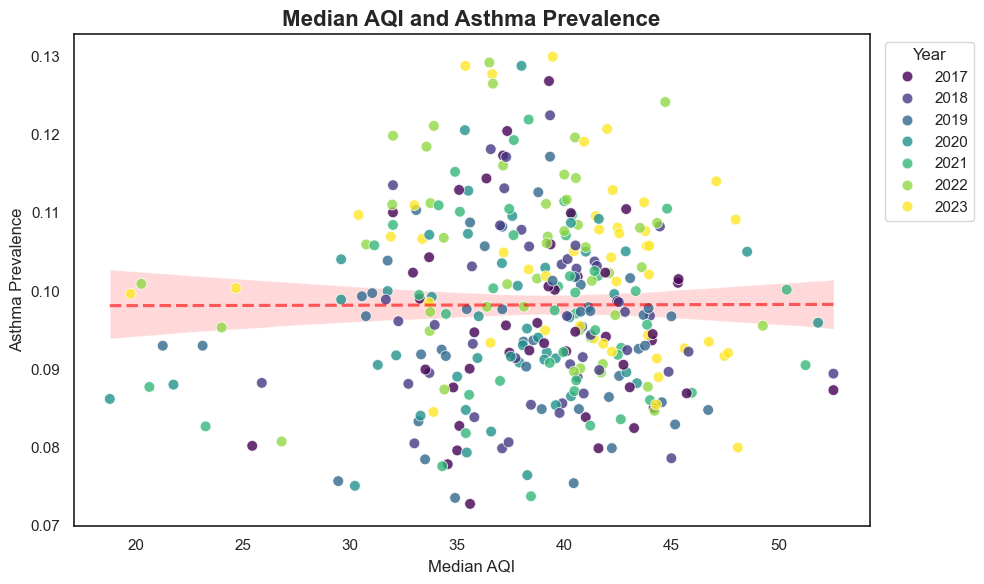

In [272]:
sns.set_theme(style = "white")

plt.figure(figsize = (10, 6))

# Adding a trendline to look for correlation
sns.regplot(
    data = merged_state, 
    x = "Median AQI", 
    y = "asthma", 
    scatter = False, 
    color = 'red', 
    line_kws = {"linestyle": "--", "alpha": 0.6}
)

# Adding scatter points, colored by Year
sns.scatterplot(
    data = merged_state, 
    x = "Median AQI", 
    y = "asthma", 
    hue = "Year", 
    palette = "viridis",
    alpha = 0.8,
    s = 60 
)

plt.title("Median AQI and Asthma Prevalence", fontsize = 16, fontweight = 'bold')
plt.xlabel("Median AQI", fontsize = 12)
plt.ylabel("Asthma Prevalence", fontsize = 12)
plt.grid(False)

plt.legend(title = "Year", bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

The points form a cloud with no clear trend, there is no strong upward or downward slope. For the same AQI of around 40, asthma prevalence varies from ~0.08 to ~0.12. This suggestis that air quality alone does not strongly explain variations in asthma prevalence on the state level per year.

Let's do an experiment with time-lagging. It may be so that exposure to poor air quality might not instantly result in an asthma diagnosis within the same calendar year, but could manifest or worsen  the following year. To test this, we need to shift the data so that Year 1's AQI is aligned with Year 2's asthma prevalence for each specific state. We can do this in pandas using the .shift() function. 

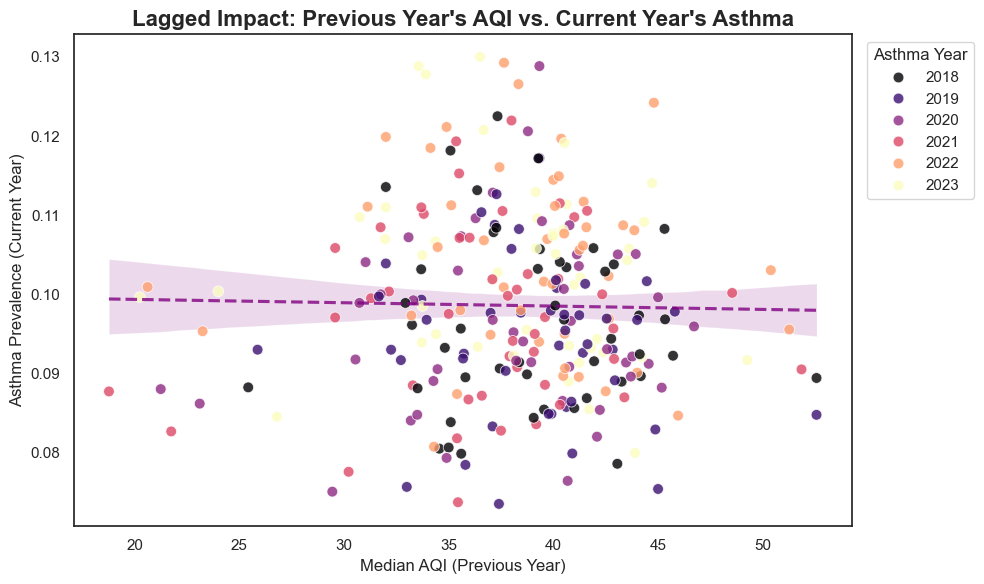

In [79]:
# Sorting the data to ensure years are in perfect order for each state
merged_state = merged_state.sort_values(by = ['State', 'Year'])

# Creating a new column: 'AQI_Previous_Year'
merged_state['AQI_Previous_Year'] = merged_state.groupby('State')['Median AQI'].shift(1)

#  Dropping empty rows (2017 does not have a "previous year")
lagged_data = merged_state.dropna(subset = ['AQI_Previous_Year', 'asthma'])

sns.set_theme(style = "white")
plt.figure(figsize = (10, 6))


sns.regplot(
    x = lagged_data['AQI_Previous_Year'], 
    y = lagged_data['asthma'], 
    scatter = False, 
    color = 'purple', 
    line_kws = {"linestyle": "--", "alpha": 0.8}
)

sns.scatterplot(
    x = lagged_data['AQI_Previous_Year'], 
    y = lagged_data['asthma'], 
    hue = lagged_data['Year'], 
    palette = "magma", 
    alpha = 0.8,
    s = 60 
)

plt.title("Lagged Impact: Previous Year's AQI vs. Current Year's Asthma", fontsize = 16, fontweight = 'bold')
plt.xlabel("Median AQI (Previous Year)", fontsize = 12)
plt.ylabel("Asthma Prevalence (Current Year)", fontsize = 12)
plt.grid(False)
plt.legend(title = "Asthma Year", bbox_to_anchor = (1.01, 1), loc = 'upper left')

plt.tight_layout()
plt.show()


Similarly as before, the experiment with time lagging also does not show any correlation.

Let's use boxplots to visualise the distribution of all states for each year. As Median AQI and Asthma prevalence are on completely different numerical scales, we will use subplots and will be able to compare the two variables despite their different scale.

C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\2671398854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\2671398854.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


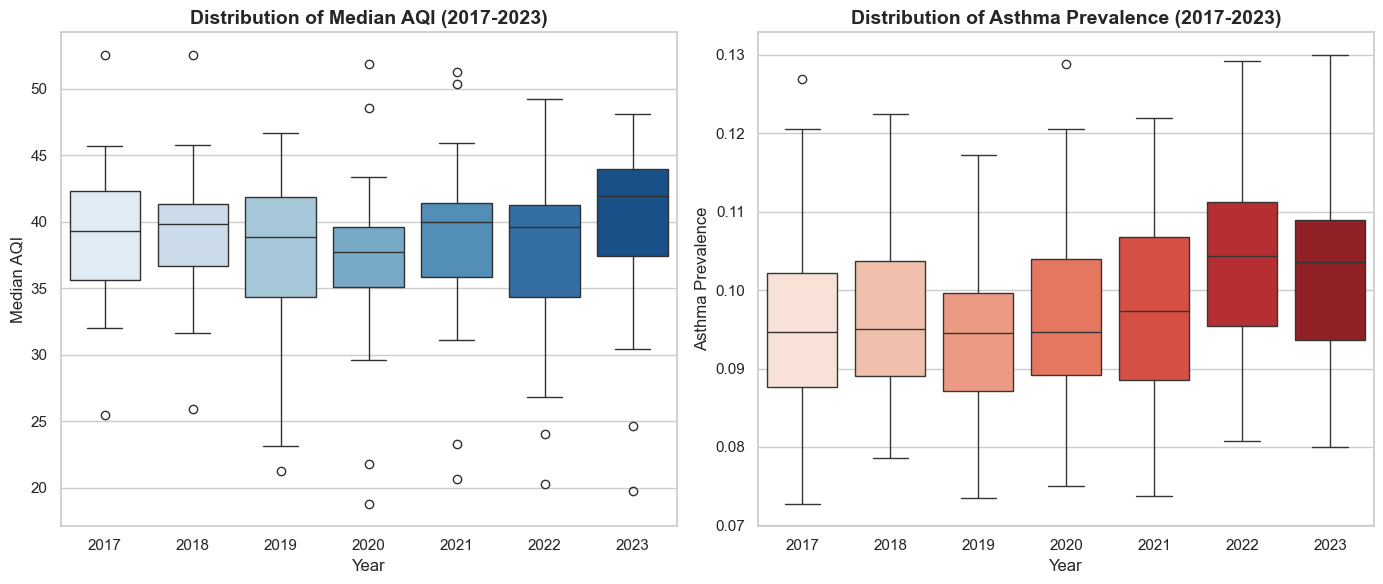

In [265]:
sns.set_theme(style = "whitegrid")

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# --- Plot 1: Median AQI Distribution over Time ---
sns.boxplot(
    data=merged_state, 
    x = "Year", 
    y = "Median AQI", 
    ax = axes[0],      
    palette = "Blues"  
)
axes[0].set_title("Distribution of Median AQI (2017-2023)", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel("Year", fontsize = 12)
axes[0].set_ylabel("Median AQI", fontsize = 12)

# --- Plot 2: Asthma Prevalence Distribution over Time ---
sns.boxplot(
    data = merged_state, 
    x = "Year", 
    y = "asthma", 
    ax = axes[1],
    palette = "Reds"
)
axes[1].set_title("Distribution of Asthma Prevalence (2017-2023)", fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel("Year", fontsize = 12)
axes[1].set_ylabel("Asthma Prevalence", fontsize = 12)

plt.tight_layout()
plt.show()

In the distribution of Median AQI we can see a dip of the median line in 2020 which probably corresponds to the Covid-19 lockdowns, taking into account also that the overall spread of the box is lower. In 2023, the entire box shifts dramatically upward, and the median jumps to its highest point in the 7-year span. This suggests a widespread, national air quality event in 2023 and could be connected the massive Canadian wildfires that blanketed much of the US in heavy smoke that year. 

For the asthma prevalence distibution we can see that from 2017 to 2019, the national median remains relatively flat at around 0.095 (9.5%). Starting in 2020 and really accelerating into 2022 and 2023, the median line goes up upward, reaching about 0.105 (10.5%). Not only is the median rising, but the entire "box" is shifting up. The lowest asthma rates (the bottom whiskers) in 2022/2023 are higher than the lowest rates in the earlier years. This indicates a systemic, national increase in asthma diagnoses or prevalence over this time period.
In 2020, AQI went down, but asthma began to creep up.

Comparing the two subplots we can see that in 2021 and 2022, AQI returned to "normal" stable levels, but asthma continued a sharp climb. While both happen to spike in 2023, the broader 7-year trend proves that the steady rise in asthma prevalence is happening independently of the year-to-year fluctuations in Median AQI.

Now let's check which states are the worst polluted and what pollutants play a role. In order to do that we will take the mean of the features for each state through 2017-2023 and show the top 10 most polluted states. We will again use Median AQI as the value that represents best the typical situation for each state.

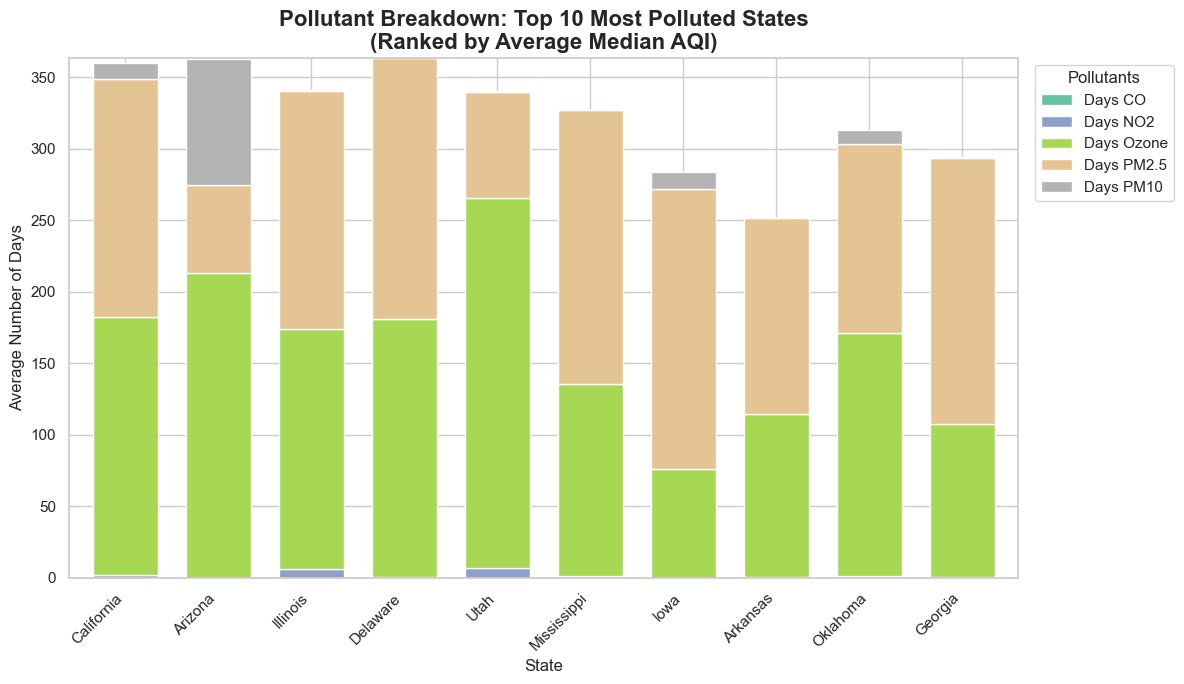

In [267]:
# Grouping by state to average out data
state_avg = merged_state.groupby('State').mean(numeric_only = True)

# Sorting by Median AQI to find the most polluted states, taking the top 10
top_polluted = state_avg.sort_values(by = 'Median AQI', ascending = False).head(10)

pollutants = ['Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']
pollutant_data = top_polluted[pollutants]

sns.set_theme(style = "whitegrid")
fig, ax = plt.subplots(figsize = (12, 7))

pollutant_data.plot(kind = 'bar', stacked = True, ax = ax, width = 0.7, colormap = 'Set2')

ax.set_title('Pollutant Breakdown: Top 10 Most Polluted States\n(Ranked by Average Median AQI)', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Average Number of Days', fontsize = 12)
ax.set_xlabel('State', fontsize = 12)

plt.xticks(rotation = 45, ha = 'right') 
ax.legend(title = 'Pollutants', bbox_to_anchor = (1.01, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

Across almost all of the top 10 most polluted states, Ozone and PM2.5 completely dominate the chart. Utah and Arizona stand out for their extremely high number of Ozone days. Utah, in particular, sees Ozone as its primary pollutant for approximately 260 days out of the year on average.  Iowa has relatively low Ozone days, but it has a massive number of days where PM2.5 is the primary pollutant (nearly 200 days). Mississippi, Georgia, and Delaware also experience a very high volume of PM2.5-heavy days. Arizona also stands out with the high level of PM10 compared to other sates. In relaity, EPA has long designated the Phoenix-Mesa area as a "Serious" Nonattainment Area for PM10. This classification means the area fails to meet the federal National Ambient Air Quality Standards (NAAQS) for 24-hour PM10, which requires maximum reduction measures to be in place.

Let's see the same plot but only for 2023, to see what is the situation in the most recent year we have.

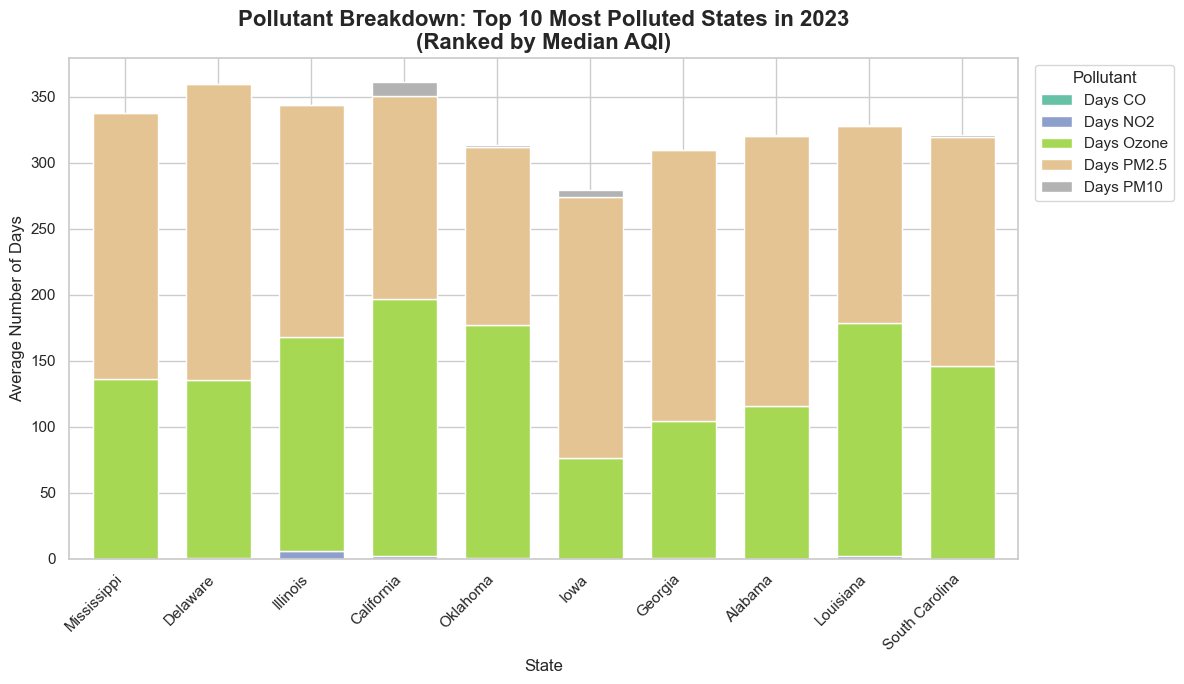

In [72]:
# Filtering and avaraging the data for only 2023
data_2023 = merged_state[merged_state['Year'] == 2023]
state_avg_2023 = data_2023.groupby('State').mean(numeric_only=True)

# Sorting by Median AQI to find the most polluted states, taking the top 10
top_polluted_2023 = state_avg_2023.sort_values(by='Median AQI', ascending=False).head(10)

pollutants = ['Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']
pollutant_data_2023 = top_polluted_2023[pollutants]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize = (12, 7))

pollutant_data_2023.plot(kind = 'bar', stacked = True, ax = ax, width = 0.7, colormap = 'Set2')


ax.set_title('Pollutant Breakdown: Top 10 Most Polluted States in 2023\n(Ranked by Median AQI)', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Average Number of Days', fontsize = 12)
ax.set_xlabel('State', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right') 

ax.legend(title = 'Pollutant', bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

Most of the states with the highest polition are the same in 2023 again, except for three new.

Now let's explore the relantionship between Median AQI and Asthma prevalence in each of the most polluted states through the years. To overcome the difference in scale of the metrics, we will convert both AQI and Asthma to Z-scores, so we can put them on the exact same axis. 

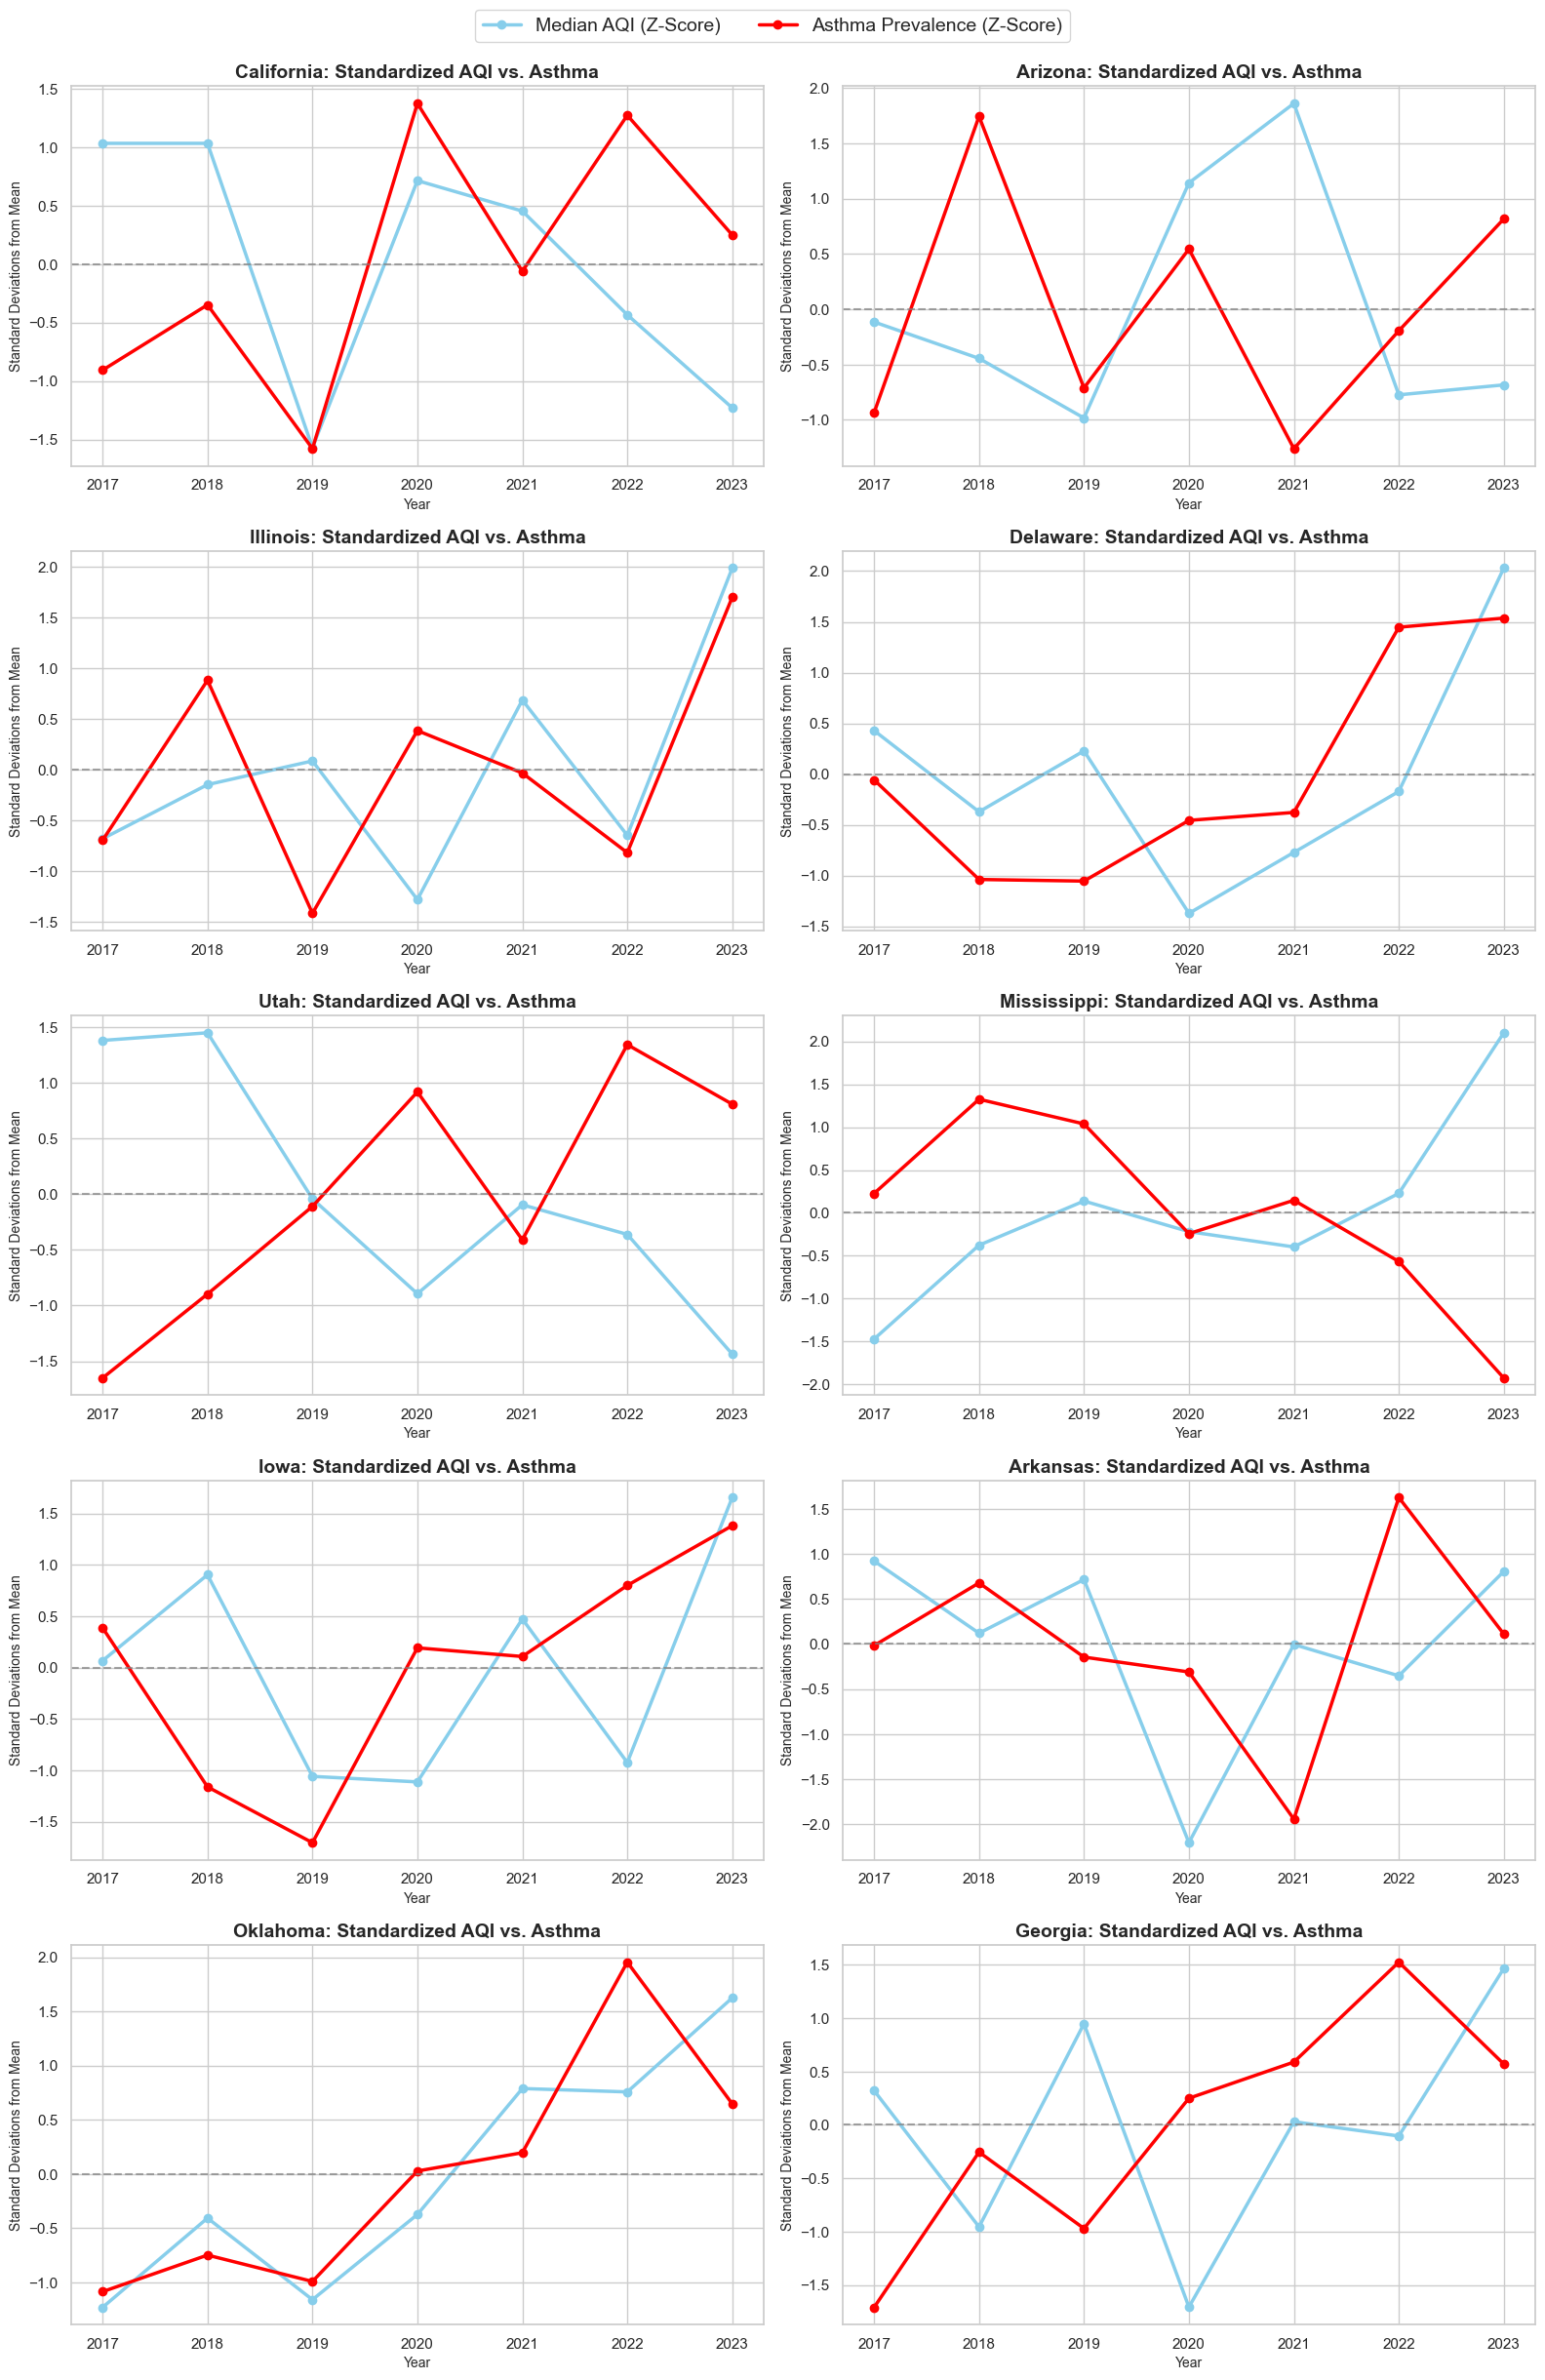

In [97]:
states_to_plot = top_polluted.index.tolist()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (16, 24))
axes = axes.flatten()

for i, state in enumerate(states_to_plot):
    state_data = merged_state[merged_state['State'] == state].sort_values('Year').copy()
    
    # Calculating Z-scores 
    state_data['AQI_Z'] = zscore(state_data['Median AQI'])
    state_data['Asthma_Z'] = zscore(state_data['asthma'])
    
    ax = axes[i]
    
    ax.plot(
        state_data['Year'].astype(str), 
        state_data['AQI_Z'], 
        color='skyblue', marker = 'o', linewidth = 2.5, label = 'Median AQI (Z-Score)'
    )
    ax.plot(
        state_data['Year'].astype(str), 
        state_data['Asthma_Z'], 
        color = 'red', marker = 'o', linewidth = 2.5, label = 'Asthma Prevalence (Z-Score)'
    )
    
    # Add a baseline at 0 which represents the exact average for that state
    ax.axhline(0, color = 'grey', linestyle = '--', alpha = 0.7)
    
    ax.set_title(f"{state}: Standardized AQI vs. Asthma", fontsize = 14, fontweight = 'bold')
    ax.set_ylabel("Standard Deviations from Mean", fontsize = 10)
    ax.set_xlabel("Year", fontsize = 10)

aqi_line = mlines.Line2D([], [], color = 'skyblue', marker = 'o', markersize = 6, linewidth = 2.5, label = 'Median AQI (Z-Score)')
asthma_line = mlines.Line2D([], [], color = 'red', marker = 'o', markersize = 6, linewidth = 2.5, label = 'Asthma Prevalence (Z-Score)')

fig.legend(
    handles = [aqi_line, asthma_line], 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.02), 
    ncol = 2, 
    fontsize = 14,
    frameon = True
)

plt.tight_layout()
plt.show()

Now let's check the correlations in figures.

In [291]:
states_to_plot = top_polluted.index.tolist()

state_correlations = {}

for state in states_to_plot:
    state_data = merged_state[merged_state['State'] == state]
    
    # Calculating the Pearson correlation between AQI and asthma
    corr = state_data['Median AQI'].corr(state_data['asthma'])
    
    state_correlations[state] = corr

# Converting the dictionary to a clean pandas DataFrame and sorting it
corr_df = pd.DataFrame.from_dict(state_correlations, orient = 'index', columns = ['Correlation (AQI vs Asthma)'])
corr_df = corr_df.sort_values(by='Correlation (AQI vs Asthma)', ascending = False)

corr_df

,Correlation (AQI vs Asthma)
Oklahoma,0.780963
Delaware,0.558303
Illinois,0.518100
Iowa,0.309601
California,0.181839
Arkansas,0.024525
Georgia,-0.137019
Arizona,-0.299359
Mississippi,-0.696069
Utah,-0.856279


Oklahoma (0.78) shows a strong positive correlation. Delaware (0.55) and Illinois (0.51) show a moderate positive relationship. Looking at the list, the correlations are completely scattered from +0.78 all the way to -0.85. Because of this inconsistency from state to state, we can confidently conclude that state-wide Median AQI is an unreliable predictor of asthma prevalence.  

Now let's move away from Median AQI and explore any correlation with the "extremes", Max AQI and Unhealthy for Sensitive Groups Days. One single day with a massive, hazardous spike in air pollution (like from a wildfire) might trigger asthma symptoms. 

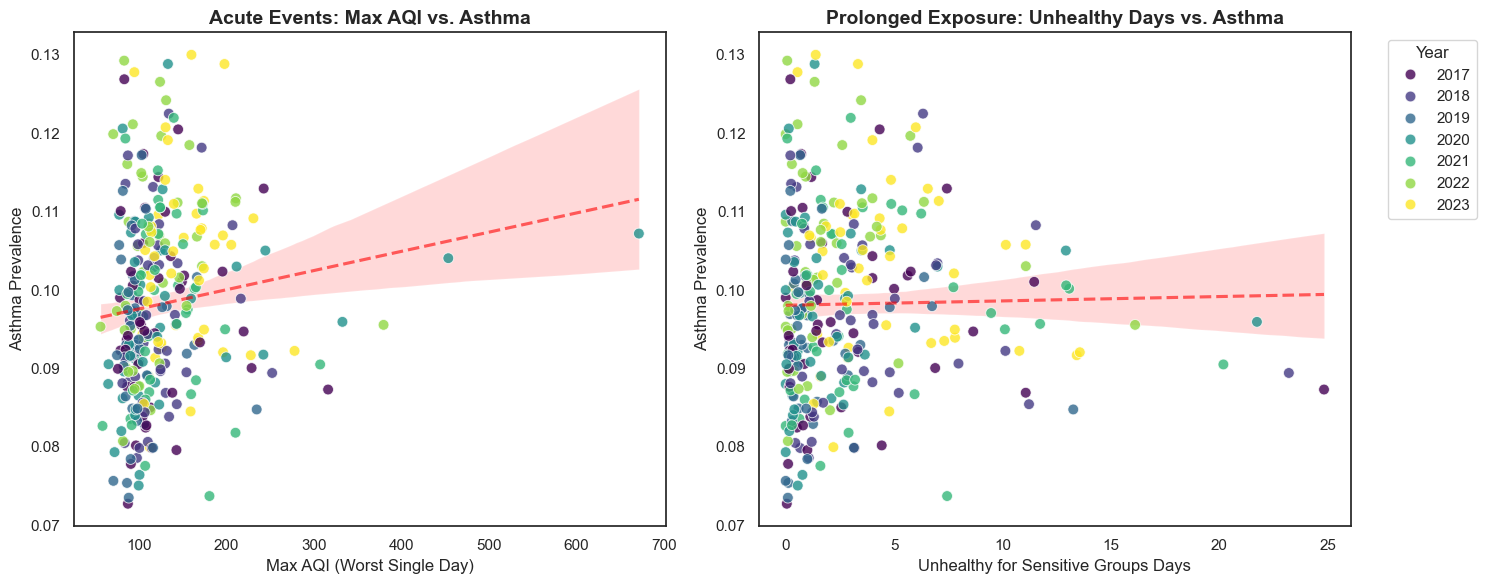

--- Pearson Correlation Coefficients ---
Max AQI vs Asthma: 0.1214
Unhealthy Days vs Asthma: 0.0181


In [84]:
sns.set_theme(style = "white")

fig, axes = plt.subplots(1, 2, figsize = (15, 6))


sns.regplot(
    x = merged_state['Max AQI'], 
    y = merged_state['asthma'], 
    scatter = False, color = 'red', line_kws = {"linestyle": "--", "alpha": 0.6}, ax = axes[0]
)
sns.scatterplot(
    x = merged_state['Max AQI'], 
    y = merged_state['asthma'], 
    hue = merged_state['Year'], palette = "viridis", alpha = 0.8, s = 60, ax = axes[0]
)
axes[0].set_title("Acute Events: Max AQI vs. Asthma", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel("Max AQI (Worst Single Day)", fontsize = 12)
axes[0].set_ylabel("Asthma Prevalence", fontsize = 12)
axes[0].grid(False)
axes[0].legend_.remove() 

# --- Plot 2: Unhealthy Days vs Asthma ---
sns.regplot(
    x = merged_state['Unhealthy for Sensitive Groups Days'], 
    y = merged_state['asthma'], 
    scatter = False, color = 'red', line_kws = {"linestyle": "--", "alpha": 0.6}, ax = axes[1]
)
sns.scatterplot(
    x = merged_state['Unhealthy for Sensitive Groups Days'], 
    y = merged_state['asthma'], 
    hue = merged_state['Year'], palette = "viridis", alpha = 0.8, s = 60, ax = axes[1]
)
axes[1].set_title("Prolonged Exposure: Unhealthy Days vs. Asthma", fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel("Unhealthy for Sensitive Groups Days", fontsize = 12)
axes[1].set_ylabel("Asthma Prevalence", fontsize = 12)
axes[1].grid(False)

axes[1].legend(title = "Year", bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

# --- Calculate and Print the Exact Correlations ---
corr_max_aqi = merged_state['Max AQI'].corr(merged_state['asthma'])
corr_unhealthy = merged_state['Unhealthy for Sensitive Groups Days'].corr(merged_state['asthma'])

print("--- Pearson Correlation Coefficients ---")
print(f"Max AQI vs Asthma: {corr_max_aqi:.4f}")
print(f"Unhealthy Days vs Asthma: {corr_unhealthy:.4f}")

Although the line slopes up in the Max AQI subplot, a Pearson correlation of 0.12 is still a very weak positive correlation. For the longer exposure of Unhealthy Days, the correlation is non-existent.

Now let's run a Multiple Regression using a mix of the pollutant metrics to predict asthma prevalence. We will use the Ordinary Least Squares (OLS) Regression Model and will drop 'Days PM10' as it very rarely gets to drive AQI. The EPA does not add pollutants together to get the Max AQI. Instead, they calculate an AQI score for each  pollutant and the highest single score becomes the Max AQI for that day. $PM_{10}$ usually stays in the "Good" or "Moderate" range and does not get to have a trend in our data.

In [238]:
features = ['Max AQI', 'Unhealthy for Sensitive Groups Days', 'Days PM2.5', 'Days Ozone']

X = model_data[features]
Y = model_data['asthma']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 asthma   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     7.744
Date:                Sat, 09 May 2026   Prob (F-statistic):           3.21e-06
Time:                        23:18:54   Log-Likelihood:                -7902.7
No. Observations:                5644   AIC:                         1.582e+04
Df Residuals:                    5639   BIC:                         1.585e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  10.1682      0.051    200.523      0.000      10.069      10.268
Max AQI                                 0.0002   8.22e-05      2.835      0.005    7.19e-05       0.000
Unhealthy for Sensitive Groups Days    -0.0050      0.002     -3.122      0.002      -0.008      -0.002
Days PM2.5                              0.0001      0.000      0.625      0.532      -0.000       0.000
Days Ozone                             -0.0003      0.000     -1.914      0.056      -0.001    7.94e-06
==============================================================================
Omnibus:                       82.767   Durbin-Watson:                   0.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.006
Skew:                           0.213   Prob(JB):                     1.58e-23
Kurtosis:                       3.514   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Combined air quality metrics explain only 5.2% of the variance in asthma rates (R-squared: 0.052), meaning that despite acute events like high ozone days or Max AQI having minor statistical significance, roughly 95% of state-wide asthma prevalence is driven by other factors. Looking at individual predictors, Days Ozone ($P=0.002$) and Max AQI ($P=0.010$) are the most reliable statistical drivers, whereas Unhealthy for Sensitive Groups Days ($P=0.062$) failed to reach significance. Despite these mathematical connections, the very small coefficients ($coef$) reveal that the real-world impact of these pollutants on the total percentage of asthma is minimal, and the warning about multicollinearity suggests that the pollutants often overlap, making it difficult for the model to isolate the effect of one from another. We also have a **multicollinearity** warning, meaning that some of our predictors are highly correlated with each other.

Let's check the multicollinearity of our features with VIF, which measures how much one variable is explained by all the other variables combined.

In [138]:
features_to_check = ['Max AQI', 'Unhealthy for Sensitive Groups Days', 'Days PM2.5', 'Days Ozone']

vif_data = epa_state[features_to_check]

vif_results = pd.DataFrame()
vif_results["Feature"] = vif_data.columns

vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) 
                       for i in range(len(vif_data.columns))]

print(vif_results.sort_values(by = "VIF", ascending = False))

                               Feature        VIF
0                              Max AQI  10.795411
2                           Days PM2.5   4.890981
3                           Days Ozone   3.664541
1  Unhealthy for Sensitive Groups Days   2.722372


The VIF for Days PM2.5 (4.89), Days Ozone (3.66), and Unhealthy Days (2.72) is withing a good range. The value of Max AQI (10.79) is relatively high, as it is determined by the highest pollutant of the day. Since that is usually either Ozone or PM2.5, Max AQI will always have a mathematical relationship with them.

### County Pollution Vs County Asthma Prevalence 

State-aggregated data about asthma prevalance could even-out regional differences. We have sourced data that has air quaility and asthma prevalence by county for the years 2018-2023. Let's explore this data to find out whether the connection changes

In [166]:
merged_county = pd.merge(
    epa, 
    county_asthma, 
    on=['Year', 'State', 'County'], 
    how='inner'
)

In [167]:
merged_county.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,asthma
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,97,54,37,0,0,194,76,0,9.5
1,Alabama,Clay,2018,110,86,24,0,0,0,0,68,54,36,0,0,0,110,0,11.0
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,93,54,37,0,0,184,93,0,10.5
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,84,54,36,0,0,286,64,0,11.0
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,71,49,33,0,0,222,0,0,10.4


Presenting the data as a scatter plot will not be ideal as there are many points with the great number of counties. Instead, let's divide all counties in three groups based on EPA's air quaility buckets (Good (0-50), Moderate (51-100), 'Unhealthy / Sensitive (101+)) and use boxplots to compare the distribution of asthma prevalence across these groups.

C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\669298424.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = merged_county, x = 'AQI_Bucket', y = 'asthma', palette = ["#00e400", "#ffff00", "#ff7e00"])


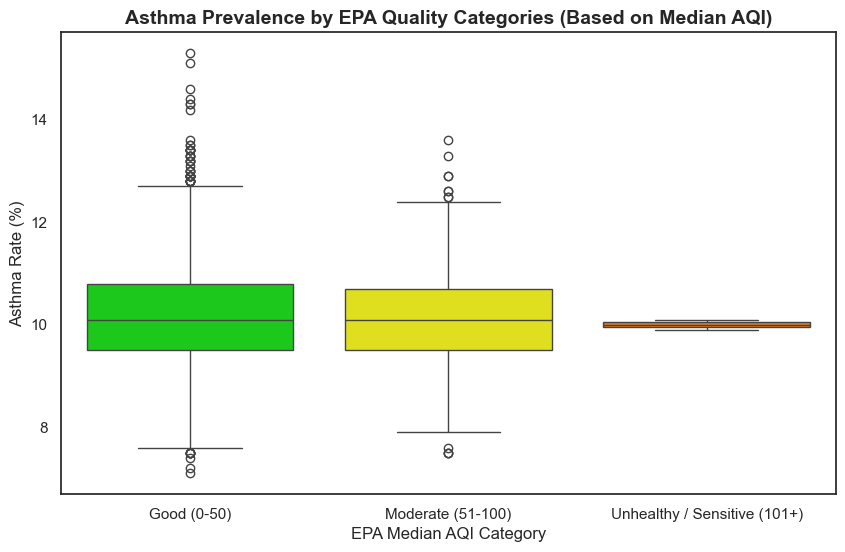

In [173]:
merged_county['AQI_Bucket'] = pd.cut(
    merged_county['Median AQI'], 
    bins = [0, 50, 100, 500], 
    labels = ['Good (0-50)', 'Moderate (51-100)', 'Unhealthy / Sensitive (101+)']
)

plt.figure(figsize = (10, 6))
sns.boxplot(data = merged_county, x = 'AQI_Bucket', y = 'asthma', palette = ["#00e400", "#ffff00", "#ff7e00"])
plt.title("Asthma Prevalence by EPA Quality Categories (Based on Median AQI)", fontsize = 14, fontweight = 'bold')
plt.ylabel("Asthma Rate (%)")
plt.xlabel("EPA Median AQI Category")
plt.show()

If air quality was a primary driver of asthma, we would expect to see the boxes "stepping up" like a staircase as we move from Good to Unhealthy. The median line is almost perfectly flat across all three categories (around 10). The fact that all three boxes overlap so much tells us that knowing a county's AQI category does nott help you predict its asthma rate. The Unhealthy / Sensitive (101+) box plot is very flat due to its sample size. In our dataset, there are only a few counties that have a Median AQI over 100. Let's see the boxplots again but this time counties are categorized based on the Max AQI.

C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\2499119478.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = merged_county, x = 'Max_AQI_Bucket', y = 'asthma',


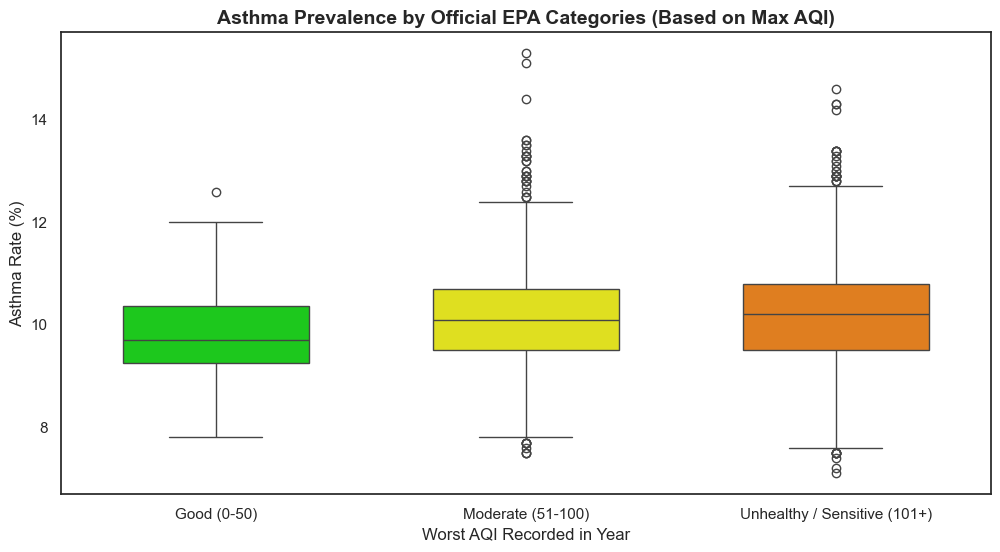

In [174]:

merged_county['Max_AQI_Bucket'] = pd.cut(
    merged_county['Max AQI'],
    bins = [0, 50, 100, 500], 
    labels = ['Good (0-50)', 'Moderate (51-100)', 'Unhealthy / Sensitive (101+)']
)

plt.figure(figsize = (12, 6))

sns.boxplot(data = merged_county, x = 'Max_AQI_Bucket', y = 'asthma', 
            palette = ["#00e400", "#ffff00", "#ff7e00"], width = 0.6)

plt.title("Asthma Prevalence by Official EPA Categories (Based on Max AQI)", fontsize = 14, fontweight = 'bold')
plt.ylabel("Asthma Rate (%)")
plt.xlabel("Worst AQI Recorded in Year")
plt.show()

Even when a county experiences "Unhealthy" air quality spikes, the typical asthma rate only increases by about 0.5 percentage points compared to the cleanest counties. This is a tiny margin, suggesting that pollution spikes are not the primary reason one county has more asthma than another. In addition the height of the boxes and the length of the whiskers are nearly identical for all three groups, proving that the same variety of asthma rates (from 8% to 12%) persists regardless of how bad the air quality gets.

Since our previous analysis on the state level showedt hat Oklahoma (0.78) has a positive correlation. Delaware (0.55) and Illinois (0.51) also had a somewhat larger score. Let's check the connection in the those states between Median AQI and asthma prevalence.

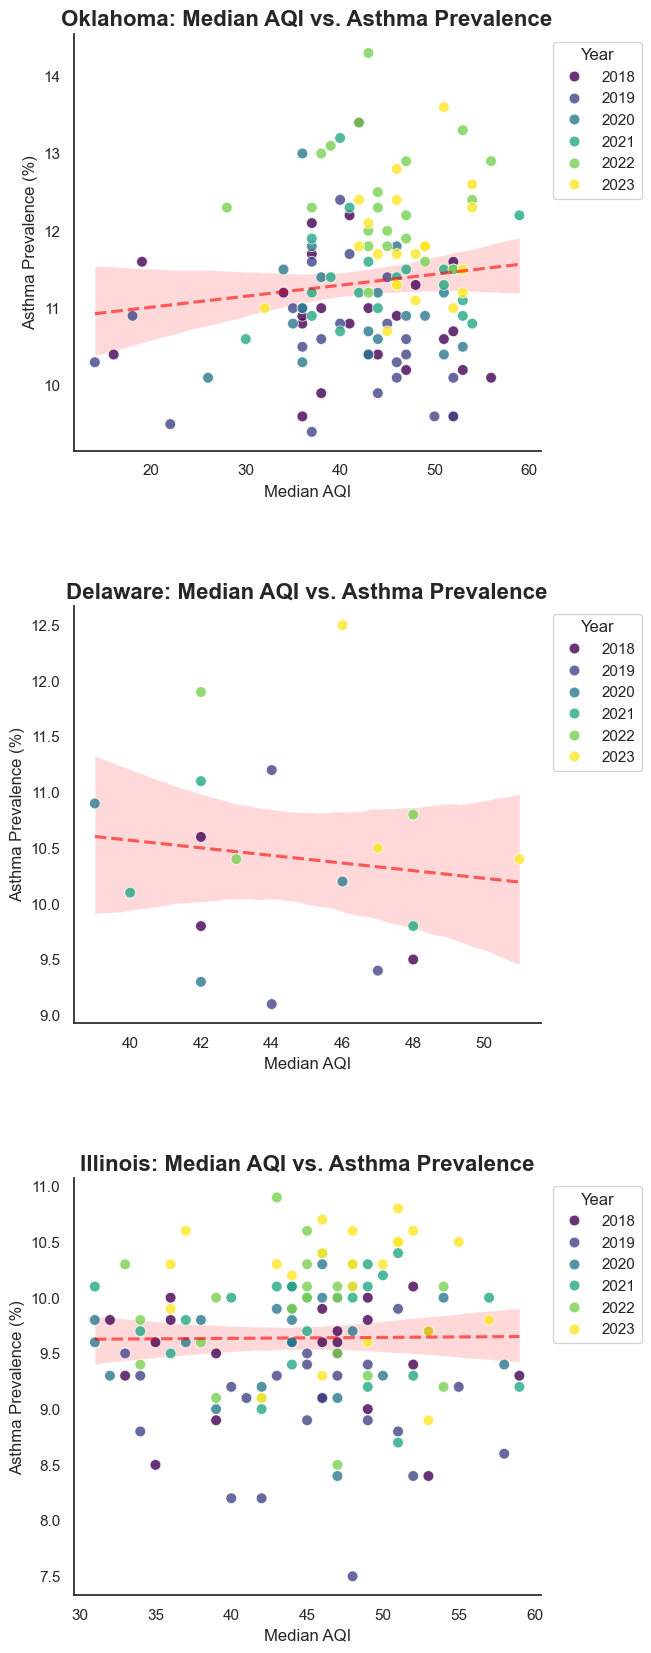

In [186]:

target_states = ['Oklahoma', 'Delaware', 'Illinois']
state_subset = merged_county[merged_county['State'].isin(target_states)].copy()

sns.set_theme(style = "white")

fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (8, 18))

for i, state in enumerate(target_states):
   
    data = state_subset[state_subset['State'] == state]
    
    # Adding the trendline 
    sns.regplot(
        data  =data, 
        x = "Median AQI", 
        y = "asthma", 
        scatter = False, 
        color = 'red', 
        line_kws = {"linestyle": "--", "alpha": 0.6},
        ax = axes[i]
    )
    
    # Adding scatter points 
    sns.scatterplot(
        data = data, 
        x = "Median AQI", 
        y = "asthma", 
        hue = "Year", 
        palette = "viridis",
        alpha = 0.8, 
        s = 60,
        ax = axes[i]
    )
    
    axes[i].set_title(f"{state}: Median AQI vs. Asthma Prevalence", fontsize = 16, fontweight = 'bold')
    axes[i].set_xlabel("Median AQI", fontsize = 12)
    axes[i].set_ylabel("Asthma Prevalence (%)", fontsize = 12)
    
    
    axes[i].grid(False)
    sns.despine(ax=axes[i])
    
    # E. Placing the legend
    axes[i].legend(title = "Year", bbox_to_anchor = (1.01, 1), loc = 'upper left')

plt.tight_layout(pad = 5.0)
plt.show()

Oklahoma shows the clearest upward slope. As the Median AQI increases, there is a noticeable, though still relatively small, climb in asthma rates. We can see tha the yellow (2023) and light green (2022) dots tend to sit higher on the y-axis than the purple (2018) dots. This suggests that asthma rates in Oklahoma have been rising over time, regardless of whether the air quality got better or worse.

Delaware’s plot looks very different because it only has 3 counties. The red trendline here is actually slightly negative, but the confidence Interval is very wide, which means that data is not enough to confirm a trend

Illinois is almost perfectly flat. Here, a county with a Median AQI of 30 has roughly the same typical asthma prevalence as a county with an AQI of 60.

Another way to look at the data we have in the county resolution is dividing the counties, according to their type. To do this, we wil use the 2023 Rural-Urban Continuum Codes (RUCC), developed by the USDA’s Economic Research Service. It distinguishes every U.S. county by its degree of urbanization and adjacency to a metro area:

Codes 1–3 (Urban): Counties in metro areas of 250,000 to 1 million+ people.

Codes 4–6 (Suburban): Non-metro counties with urban populations of 2,500 to 20,000+, typically adjacent to metro hubs.

Codes 7–9 (Rural): "Noncore" counties with urban populations of less than 2,500, often completely physically isolated from major cities.

First let's ask the question: Regardless of air quality, **does the degree of urbanization itself act as a predictor for asthma prevalence**?

In [214]:
# Loading the raw USDA file
rucc_raw = pd.read_csv('data/Ruralurbancontinuumcodes2023.csv', encoding='latin1')

# Filtering for the 2023 RUCC Attribute
rucc = rucc_raw[rucc_raw['Attribute'] == 'RUCC_2023'].copy()

# Defining the Mapping Function
# 1-3 (Metro), 4-6 (Suburban/Adjacent), 7-9 (Rural)
def map_rucc(val):
    try:
        code = int(float(val))
        if code <= 3: return 'Urban'
        elif code <= 6: return 'Suburban'
        else: return 'Rural'
    except: return 'Unknown'

rucc['Density_Label'] = rucc['Value'].apply(map_rucc)

# 4. Standardizing the data
def extreme_clean(name):
    if pd.isna(name): return ""
    return str(name).upper().replace(' COUNTY', '').replace(' PARISH', '').replace('.', '').replace("'", "").replace(' ', '')

rucc['ST_ABBR'] = rucc['State'].astype(str).str.upper().str.strip()
rucc['CO_CLEAN'] = rucc['County_Name'].apply(extreme_clean)

rucc[['ST_ABBR', 'County_Name', 'CO_CLEAN', 'Density_Label']].head()

,ST_ABBR,County_Name,CO_CLEAN,Density_Label
1,AL,Autauga County,AUTAUGA,Urban
4,AL,Baldwin County,BALDWIN,Urban
7,AL,Barbour County,BARBOUR,Suburban
10,AL,Bibb County,BIBB,Urban
13,AL,Blount County,BLOUNT,Urban


In [215]:
# State Mapping Dictionary
state_map = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR', 'CALIFORNIA': 'CA',
    'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE', 'FLORIDA': 'FL', 'GEORGIA': 'GA',
    'HAWAII': 'HI', 'IDAHO': 'ID', 'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA',
    'KANSAS': 'KS', 'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV', 'NEW HAMPSHIRE': 'NH',
    'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY', 'NORTH CAROLINA': 'NC',
    'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK', 'OREGON': 'OR', 'PENNSYLVANIA': 'PA',
    'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN',
    'TEXAS': 'TX', 'UTAH': 'UT', 'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY'
}

Standardizing State Abbreviation
merged_county['ST_ABBR_CLEAN'] = merged_county['State'].astype(str).str.upper().map(state_map).fillna(merged_county['State'].astype(str).str.upper())

# Cleaning county names 
merged_county['CO_CLEAN'] = merged_county['County'].apply(extreme_clean)


merged_county[['ST_ABBR_CLEAN', 'County', 'CO_CLEAN']].head()

,ST_ABBR_CLEAN,County,CO_CLEAN
0,AL,Baldwin,BALDWIN
1,AL,Clay,CLAY
2,AL,Colbert,COLBERT
3,AL,DeKalb,DEKALB
4,AL,Elmore,ELMORE


In [ ]:
# Merging the data
merged_final = pd.merge(
    merged_county, 
    rucc[['ST_ABBR', 'CO_CLEAN', 'Density_Label']], 
    left_on=['ST_ABBR_CLEAN', 'CO_CLEAN'], 
    right_on=['ST_ABBR', 'CO_CLEAN'], 
    how='inner'
)

In [233]:
merged_final.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,...,State_Abbr,County_Match,ST_ABBR_x,CO_CLEAN,NAME_CLEAN,NAME_KEY,ST_ABBR_CLEAN,ST_ABBR_y,Density_Label,P90_AQI_Bucket
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,AL,BALDWIN,ALABAMA,BALDWIN,BALDWIN,BALDWIN,AL,AL,Urban,Moderate
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,AL,CLAY,ALABAMA,CLAY,CLAY,CLAY,AL,AL,Rural,Moderate
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,AL,COLBERT,ALABAMA,COLBERT,COLBERT,COLBERT,AL,AL,Urban,Moderate
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,AL,DEKALB,ALABAMA,DEKALB,DEKALB,DEKALB,AL,AL,Suburban,Moderate
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,AL,ELMORE,ALABAMA,ELMORE,ELMORE,ELMORE,AL,AL,Urban,Good


C:\Users\kalina\AppData\Local\Temp\ipykernel_10680\2887246599.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


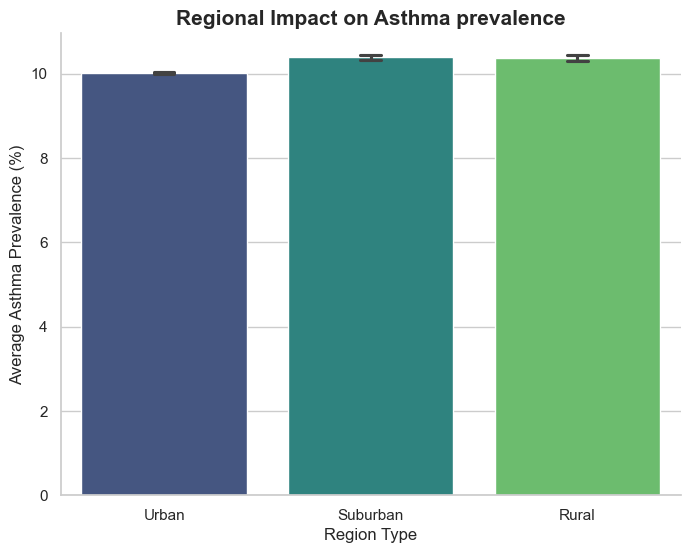

,mean,std,count
Density_Label,,,
Urban,10.018,0.960,3652
Suburban,10.389,0.892,983
Rural,10.372,1.068,1009


In [292]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8, 6))


# 'ci=95' adds a confidence interval (error bar)
sns.barplot(
    data = merged_final, 
    x = 'Density_Label', 
    y = 'asthma', 
    order = ['Urban', 'Suburban', 'Rural'],
    palette = 
    'viridis',
    capsize = .1
)

plt.ylabel("Average Asthma Prevalence (%)", fontsize = 12)
plt.xlabel("Region Type", fontsize = 12)
plt.title("Regional Impact on Asthma prevalence", fontsize = 15, fontweight = 'bold')

sns.despine()
plt.show()

# Calculating summary statistics
summary = merged_final.groupby('Density_Label')['asthma'].agg(['mean', 'std', 'count']).reindex(['Urban', 'Suburban', 'Rural'])
summary.round(3)

Both Suburban (10.39%) and Rural (10.37%) areas exhibit higher average asthma prevalence compared to Urban (10.02%) regions. While the Suburban mean is technically the highest in this dataset, the overlapping error bars between Suburban and Rural categories suggest their health outcomes are effectively equivalent, whereas the distinct gap between these groups and the Urban bar proves that living outside a major city is a consistent risk factor. This is likely due to better access to specialized respiratory care and preventative healthcare infrastructure, which offsets the higher baseline pollution typically found in metropolitan environments.

Let's run an ANOVA test on all three groups to see if geography makes a statistically significant difference overall.

In [294]:
urban_data = merged_final[merged_final['Density_Label'] == 'Urban']['asthma'].dropna()
suburban_data = merged_final[merged_final['Density_Label'] == 'Suburban']['asthma'].dropna()
rural_data = merged_final[merged_final['Density_Label'] == 'Rural']['asthma'].dropna()

f_stat, p_value = f_oneway(urban_data, suburban_data, rural_data)

pd.DataFrame({
    'Metric': ['ANOVA: Urban vs. Suburban vs. Rural'],
    'F-Statistic': [round(f_stat, 2)],
    'P-Value': [p_value]
}).set_index('Metric')

,F-Statistic,P-Value
Metric,,
ANOVA: Urban vs. Suburban vs. Rural,90.43,2.207461e-39


The test confirmed with overwhelming statistical significance ($p < 0.001$) that baseline asthma prevalence is fundamentally unequal across geographical lines, proving that where a patient lives permanently alters their baseline health risk."

Now let's wrap-up the county-resolution analysis with a regression analysis.

In [237]:
# 1. Select the features we want to test
features = ['Max AQI', 'Unhealthy for Sensitive Groups Days', 'Days PM2.5', 'Days Ozone']

# 2. Prepare the data (Ensure no missing values in these specific columns)
model_data = merged_final[features + ['asthma']].dropna()

X = model_data[features]
y = model_data['asthma']

# 3. Add a constant (the Intercept)
# This represents the baseline asthma rate when all pollution is zero
X = sm.add_constant(X)

# 4. Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X).fit()

# 5. Display the results
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 asthma   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     7.744
Date:                Sat, 09 May 2026   Prob (F-statistic):           3.21e-06
Time:                        23:18:10   Log-Likelihood:                -7902.7
No. Observations:                5644   AIC:                         1.582e+04
Df Residuals:                    5639   BIC:                         1.585e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  10.1682      0.051    200.523      0.000      10.069      10.268
Max AQI                                 0.0002   8.22e-05      2.835      0.005    7.19e-05       0.000
Unhealthy for Sensitive Groups Days    -0.0050      0.002     -3.122      0.002      -0.008      -0.002
Days PM2.5                              0.0001      0.000      0.625      0.532      -0.000       0.000
Days Ozone                             -0.0003      0.000     -1.914      0.056      -0.001    7.94e-06
==============================================================================
Omnibus:                       82.767   Durbin-Watson:                   0.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.006
Skew:                           0.213   Prob(JB):                     1.58e-23
Kurtosis:                       3.514   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared value is 0.005, meaning that our four air quality metrics combined only explain 0.5% of the variance in county-level asthma prevalence. Asthma is an incredibly complex disease. While air pollution is a known trigger, this low number proves that county-wide asthma rates are driven almost entirely by other factors not in this model (like poverty, healthcare access, smoking rates, genetics, or indoor air quality). Max AQI has p-value of 0.005 This is statistically significant. The coefficient is positive (0.0002), meaning as the worst AQI day gets worse, asthma rates slightly increase. However, the effect size is very tiny.

To fix the multicollinearity issue, let's simplify the air pollution metric to just Max AQI and convert the Density_Label into Dummy Variables. Because regression models only understand numbers (not words like "Rural"), we have to create binary columns (1 for Yes, 0 for No). We will use Urban as our baseline, meaning the model will measure how much worse or better Suburban and Rural areas are compared to the city.

In [240]:
model_data = merged_final.copy()

dummies = pd.get_dummies(model_data['Density_Label'], prefix='Region', dtype=float)
model_data = pd.concat([model_data, dummies], axis=1)


features = ['Max AQI', 'Region_Suburban', 'Region_Rural']

model_data_clean = model_data[features + ['asthma']].dropna()

X = model_data_clean[features]
y = model_data_clean['asthma']


X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 asthma   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     62.38
Date:                Sat, 09 May 2026   Prob (F-statistic):           1.14e-39
Time:                        23:36:32   Log-Likelihood:                -7826.1
No. Observations:                5644   AIC:                         1.566e+04
Df Residuals:                    5640   BIC:                         1.569e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.9922      0.019    525.231      0.000       9.955      10.030
Max AQI             0.0002   7.83e-05      2.474      0.013    4.02e-05       0.000
Region_Suburban     0.3721      0.035     10.691      0.000       0.304       0.440
Region_Rural        0.3532      0.034     10.251      0.000       0.286       0.421
==============================================================================
Omnibus:                       75.479   Durbin-Watson:                   0.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.890
Skew:                           0.223   Prob(JB):                     4.99e-20
Kurtosis:                       3.423   Cond. No.                         646.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

By simplifying the model, the multicollinearity warning was eliminated and the R-squared increased and the model now explains 3.2% of the variance in asthma rates, which is still very small. The coefficients for the regions both have a P-value of 0.000, meaning we have absolute statistical certainty that geography plays a role independent of pollution. If a county is Suburban, you mathematically add 0.37% to the baseline asthma rate, regardless of the air quality.If a county is Rural, you add 0.35% to the baseline asthma rate.


###  California pollution vs California ED asthma visits by year

Now let's investigated  whether air quality affects asthma-rlated visit to emergency departmens (EDs). The California datase contains counts and rates (per 10,000 residents) of asthma ED visits among Californians, from 2015 to 2023.

In [245]:
asthma_ED_Cal.head()

,County,Year,asthma_ED_rate
0,Alameda,2015,64.3
1,Alpine,2015,0.0
2,Amador,2015,58.4
3,Butte,2015,50.2
4,Calaveras,2015,48.0


In [246]:
# Merging the data with our dataset with asthma prevalance by county
merged_final['County'] = merged_final['County'].str.strip()
asthma_ED_Cal['County'] = asthma_ED_Cal['County'].str.strip()

cal_merged = pd.merge(
    merged_final, 
    asthma_ED_Cal, 
    on = ['County', 'Year'], 
    how = 'inner' 
)

review_columns = [
    'County', 
    'Year', 
    'asthma',                 
    'asthma_ED_rate',        
    'Max AQI', 
    'Median AQI', 
    'Unhealthy for Sensitive Groups Days', 
    'Days PM2.5', 
    'Days Ozone'
]

cal_merged[review_columns].head()

,County,Year,asthma,asthma_ED_rate,Max AQI,Median AQI,Unhealthy for Sensitive Groups Days,Days PM2.5,Days Ozone
0,Santa Cruz,2018,9.5,27.9,194,39,1,316,0
1,Alameda,2018,8.3,48.6,248,57,5,342,22
2,Amador,2018,9.5,44.3,129,40,6,0,364
3,Butte,2018,10.1,42.2,682,59,22,216,148
4,Calaveras,2018,9.8,52.3,160,58,14,293,71


Let's run a correlation matrix to look for connections between our features.

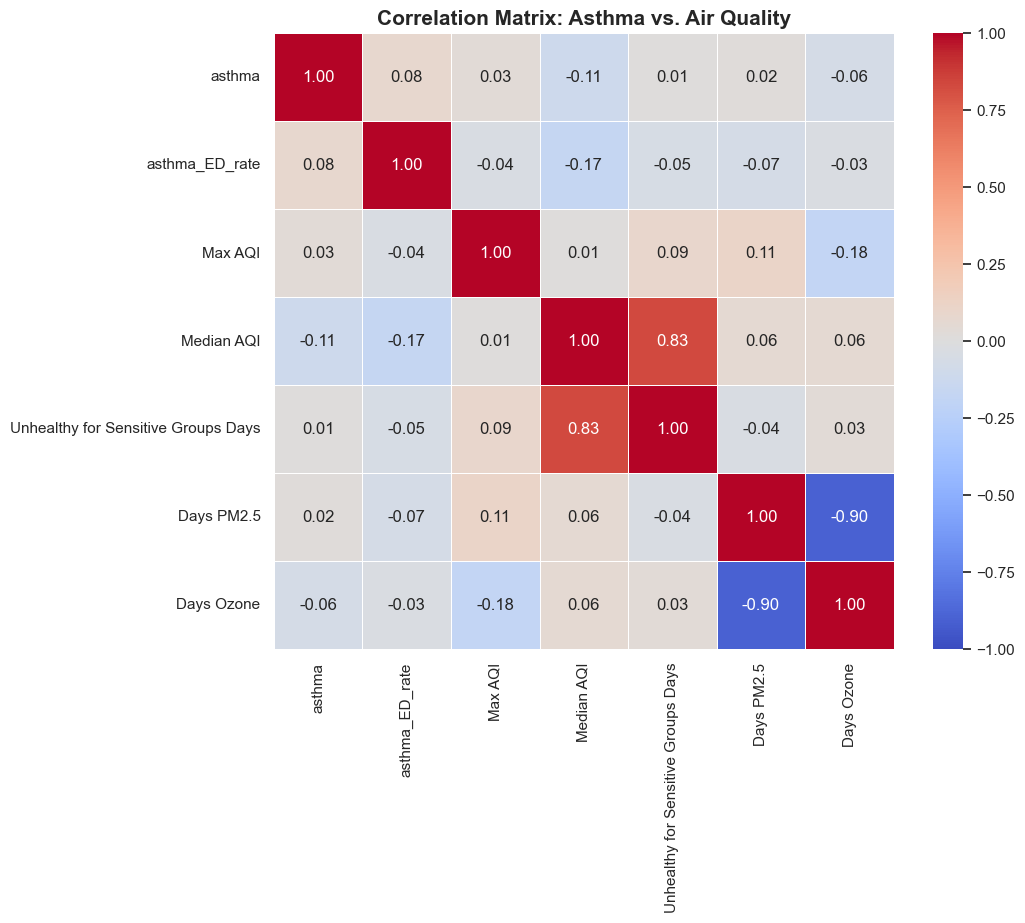

,asthma,asthma_ED_rate,Max AQI,Median AQI,Unhealthy for Sensitive Groups Days,Days PM2.5,Days Ozone
asthma,1.000,0.082,0.034,-0.110,0.014,0.018,-0.064
asthma_ED_rate,0.082,1.000,-0.038,-0.168,-0.048,-0.069,-0.025
Max AQI,0.034,-0.038,1.000,0.008,0.092,0.111,-0.181
Median AQI,-0.110,-0.168,0.008,1.000,0.829,0.060,0.058
Unhealthy for Sensitive Groups Days,0.014,-0.048,0.092,0.829,1.000,-0.037,0.034
Days PM2.5,0.018,-0.069,0.111,0.060,-0.037,1.000,-0.905
Days Ozone,-0.064,-0.025,-0.181,0.058,0.034,-0.905,1.000


In [247]:
corr_features = [
    'asthma', 
    'asthma_ED_rate', 
    'Max AQI', 
    'Median AQI', 
    'Unhealthy for Sensitive Groups Days', 
    'Days PM2.5', 
    'Days Ozone'
]

correlation_matrix = cal_merged[corr_features].corr()

plt.figure(figsize = (10, 8))
sns.heatmap(
    correlation_matrix, 
    annot = True,          
    cmap = 'coolwarm',     
    fmt = ".2f",           
    linewidths = 0.5,
    vmin = -1, vmax = 1    
)

plt.title("Correlation Matrix: Asthma vs. Air Quality", fontsize = 15, fontweight = 'bold')
plt.show()

correlation_matrix.round(3)

The correlation between general asthma prevalence and asthma_ED_rate is only 0.082. This proves that a county having a high rate of people with asthma does not automatically mean they have a high rate of people going to the emergency room for it. It could be the case that an ED visit is less an indicator of the disease's presence and more an indicator of failed disease management. The asthma ED rate row shows negative correlation with all air quality metrics.

The study [California Wildfire Impact on Asthma and COPD Hospitalizations](https://journals.sagepub.com/doi/10.4187/respcare.20223777483) found that an increase in hospital admissions for asthma and chronic obstructive pulmonary disease (COPD) were seen during November’s high wildfire months in 2018 and 2019 compared to low fire season Novembers in 2020 and 2021, yet not statistically significant. On the other hand, pediatric asthma patients did have a statistically significant increase in hospitalizations during these high wildfire months compared to the low season months. 

Let's explore the changes in ED visits and Max AQI, both avaraged for the whole state, through the years. Because these two metrics are on completely different scales, we will use a Dual-Axis Line Chart. This allows us to overlay the two trends perfectly on top of each other. We will look at 2018 and 2020, when according to [Wikipedia](https://en.wikipedia.org/wiki/List_of_California_wildfires), california experienced exceptionally large wild fires.

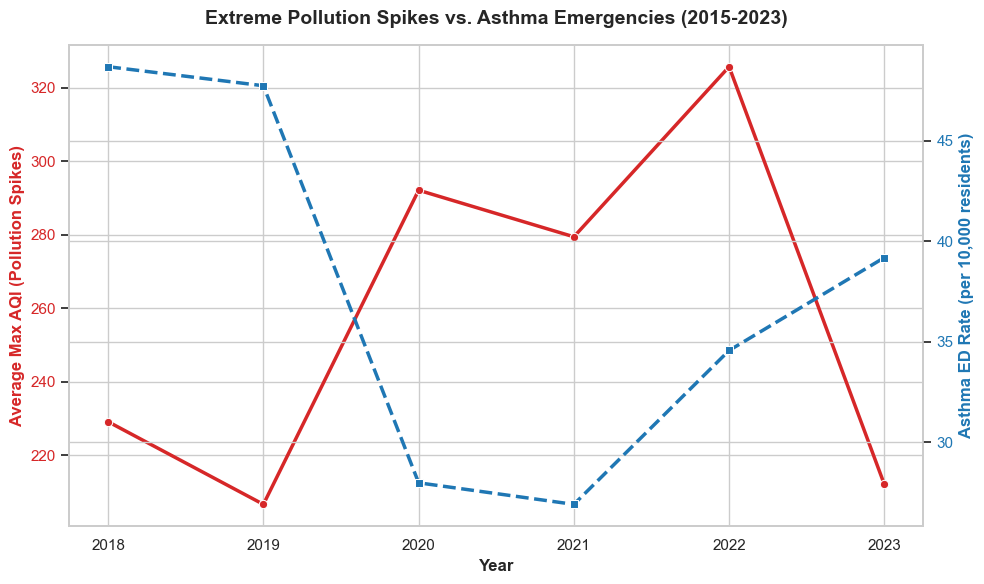

,Year,Max AQI,asthma_ED_rate
0,2018,229.06,48.67
1,2019,206.56,47.73
2,2020,292.11,27.97
3,2021,279.42,26.90
4,2022,325.74,34.56
5,2023,212.00,39.18


In [250]:
yearly_trends = cal_merged.groupby('Year')[['Max AQI', 'asthma_ED_rate']].mean().reset_index()


sns.set_theme(style = "whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting  Max AQI on the primary y-axis
color = '#d62728'
ax1.set_xlabel('Year', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Average Max AQI (Pollution Spikes)', color = color, fontsize = 12, fontweight = 'bold')
sns.lineplot(data = yearly_trends, x = 'Year', y = 'Max AQI', ax = ax1, color = color, marker = 'o', linewidth = 2.5)
ax1.tick_params(axis = 'y', labelcolor = color)

# Creating a secondary y-axis that shares the same x-axis
ax2 = ax1.twinx()  

# Plotting Asthma ED Rates on the right side
color = '#1f77b4'
ax2.set_ylabel('Asthma ED Rate (per 10,000 residents)', color=color, fontsize=12, fontweight='bold')
sns.lineplot(data=yearly_trends, x = 'Year', y = 'asthma_ED_rate', ax = ax2, color = color, marker = 's', linestyle = '--', linewidth = 2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Extreme Pollution Spikes vs. Asthma Emergencies (2015-2023)", 
          fontsize = 14, fontweight = 'bold', pad = 15)
fig.tight_layout() 
plt.show()

yearly_trends.round(2)

We can clearly see a massive divergence in 2020.California experienced historic, catastrophic wildfires in that and the red line captures this, shooting up from a Max AQI of 206 to 292. One would expect hospitals to be flooded with asthma patients as a result. Instead, the blue line plummets from 47.7 down to 27.9. Most likely, the reason is the 2020 lockdowns, when people stayed indoors, schools were closed, and traffic was minimal. Patients absiatined from going to the Emergency Room for fear of catching the virus. In 2023, air quality improves drastically from 325 down to 212, however, asthma ED visits rose during that same period from 34.5 to 39.1. This could be again explained as the time when after the pandemic thing got back to normal.

Let's run a multipleregression on this California dataset. Since we are now focusing on acute emergencies, we will set asthma_ED_rate as our Dependent Variable (Y). We can use the general asthma prevalence as a baseline feature, alongside the air quality metrics, to see how much each factor contributes to emergency room visits.

In [253]:
features = ['asthma', 'Max AQI', 'Unhealthy for Sensitive Groups Days', 'Days PM2.5', 'Days Ozone']

model_data = cal_merged[features + ['asthma_ED_rate']].dropna()

X = model_data[features]
Y = model_data['asthma_ED_rate'] 

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         asthma_ED_rate   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     4.748
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000319
Time:                        00:08:10   Log-Likelihood:                -1645.3
No. Observations:                 392   AIC:                             3303.
Df Residuals:                     386   BIC:                             3326.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  56.9481     12.392      4.596      0.000      32.584      81.312
asthma                                  1.2181      0.980      1.243      0.214      -0.708       3.144
Max AQI                                -0.0022      0.002     -1.356      0.176      -0.005       0.001
Unhealthy for Sensitive Groups Days    -0.0316      0.035     -0.893      0.372      -0.101       0.038
Days PM2.5                             -0.0914      0.021     -4.382      0.000      -0.132      -0.050
Days Ozone                             -0.0845      0.020     -4.185      0.000      -0.124      -0.045
==============================================================================
Omnibus:                       76.495   Durbin-Watson:                   1.205
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.675
Skew:                           1.154   Prob(JB):                     3.11e-28
Kurtosis:                       4.558   Cond. No.                     9.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared of 0.058 testifies that this model is also very weak. All variables combined only explain 5.8% of the variance in asthma ED visits. The F-statistic of 0.0003 proves the model is statistically significant overall. The tiny relationships that do exist are real, but still tiny. The warning of strong multicollinearity is another issue we want to attempt to improve.

Let's make this attempt. We will drop all overlapping air metrics and keep only Max AQI. Because 2020 is exceptional due to the lockdowns yjay stopped people from going to the hospital, we will create a dummy variable (is_2020) to try "control" for this massive anomaly. We will add the Region categories back in (Urban/Suburban/Rural) to account for structural healthcare differences.

In [256]:
model_data = cal_merged.copy()

model_data['is_2020'] = (model_data['Year'] == 2020).astype(float)

if 'Density_Label' in model_data.columns:
    dummies = pd.get_dummies(model_data['Density_Label'], prefix = 'Region', dtype = float)
    model_data = pd.concat([model_data, dummies], axis = 1)
    

    features = ['Max AQI', 'is_2020', 'Region_Suburban', 'Region_Rural']
else:
    features = ['Max AQI', 'is_2020']

model_data_clean = model_data[features + ['asthma_ED_rate']].dropna()

X = model_data_clean[features]
Y = model_data_clean['asthma_ED_rate']

X = sm.add_constant(X)

final_model = sm.OLS(Y, X).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         asthma_ED_rate   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     13.24
Date:                Mon, 11 May 2026   Prob (F-statistic):           4.03e-10
Time:                        00:18:56   Log-Likelihood:                -1631.8
No. Observations:                 392   AIC:                             3274.
Df Residuals:                     387   BIC:                             3293.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              37.5634      1.066     35.224      0.000      35.467      39.660
Max AQI            -0.0025      0.002     -1.616      0.107      -0.006       0.001
is_2020           -11.3910      2.113     -5.391      0.000     -15.545      -7.237
Region_Suburban     6.4913      2.015      3.222      0.001       2.530      10.453
Region_Rural       10.3178      2.550      4.046      0.000       5.304      15.332
==============================================================================
Omnibus:                       76.528   Durbin-Watson:                   1.249
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              127.301
Skew:                           1.151   Prob(JB):                     2.27e-28
Kurtosis:                       4.579   Cond. No.                     1.98e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared of 0.120 doubled from the previous model and now the model explain 12% of the variance in emergency visits. The  is_2020 coef at -11.3910 and P = 0.000 means that simply being the year 2020 caused emergency room visits to drop by an average of 11.4 visits per 10,000 residents, controlling for all other factors. This indicates a lockdown effect. Region_Suburban has coef 6.4913 and P = 0.001, indicatig that suburban counties have ~6.5 more ED visits per 10,000 than urban ones. Region_Rural has coef 10.3178 and P = 0.000, suggesting rural counties have ~10.3 more ED visits per 10,000 than urban ones. This indicates that geography and infrastructure are  significant, independent drivers of health outcomes. On the othe has Max AQI has a coef -0.0025 and P = 0.107, meaning that in this specific model, Max AQI is not statistically significant. 

###   Minnesota pollution vs Minnesota ED asthma visits per month


Finally, we have the Minnesota dataset to take a look at. It was the only one that has asthma-related ED visits (counted) with monthly resolution. It only covers one year - 2022. Let's see if there is a seasonality in asthma-related ED visits.

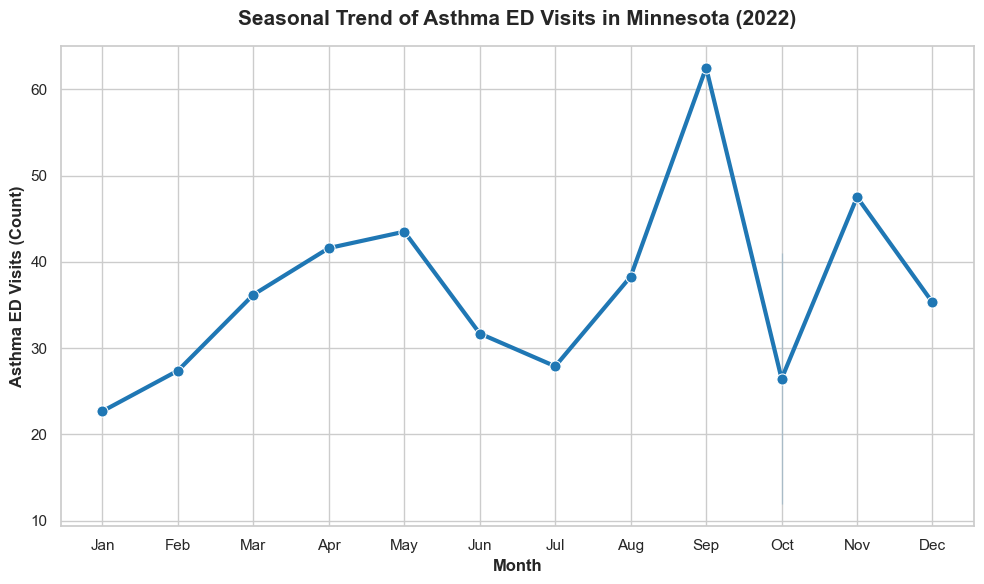

In [275]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

asthma_MN_monthly['Month'] = pd.Categorical(asthma_MN_monthly['Month'], categories = month_order, ordered = True)

plot_data = asthma_MN_monthly.sort_values('Month')

plt.figure(figsize = (10, 6))
sns.set_theme(style = "whitegrid")

sns.lineplot(
    data = plot_data, 
    x = 'Month', 
    y = 'Count', 
    marker = 'o',         
    color = '#1f77b4',     
    linewidth = 3, 
    markersize = 8
)

plt.title("Seasonal Trend of Asthma ED Visits in Minnesota (2022)", fontsize = 15, fontweight = 'bold', pad = 15)
plt.xlabel("Month", fontsize = 12, fontweight = 'bold')
plt.ylabel("Asthma ED Visits (Count)", fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.show()

The sharp peak in September with 62.5 visits, nearly three times the January figure, proves a well-established fact in many studies. This spike is caused by kids returning to school, mixing indoors and spreading respiratory viruses, which could trigger asthma attacks. In addition, according to an article on Entira Family Clinics' website, in Minnesota, tree pollen is the primary culprit in early spring allergies, with asthma and allergies being closely linked. These trees release pollen from late March through May and we can see that ED visits rise during this period. In November, there is another peak, which may be connected to a message from the Minnesota Department of Health in 2018 that claimed the state is seeing more asthma-related emergency room visits in the fall due to climate change triggering more pollen, hotter temperatures and higher levels of carbon dioxide in the air.

Now let's check this data against EPA monthly air-quality dataset for Minnesota in 2022. First the data will be aggregated.

In [282]:
mn_monthly_aqi['Month'] = pd.Categorical(mn_monthly_aqi['Month'], categories=month_order, ordered=True)
asthma_MN_monthly['Month'] = pd.Categorical(asthma_MN_monthly['Month'], categories=month_order, ordered=True)

final_mn_merged = pd.merge(asthma_MN_monthly, mn_monthly_aqi, on='Month').sort_values('Month')
final_mn_merged = final_mn_merged[final_mn_merged['Year'] == 2022].copy()
final_mn_merged.head()

,Year,Month,Count,Median_AQI,Max_AQI
4,2022,Jan,22.7,34.0,96
3,2022,Feb,27.4,35.0,167
7,2022,Mar,36.2,38.0,69
0,2022,Apr,41.6,35.0,65
8,2022,May,43.5,39.0,125


Let's calculate the Pearson Correlation Matrix and explore with scatter plots if there is a connection between air quality and asthma ED visits. We will check the number of visits against both Median AQI and Max AQI.

In [289]:
# Calculating the Pearson Correlation Matrix
correlation = final_mn_merged[['Count', 'Median_AQI', 'Max_AQI']].corr()
correlation.round(2)

,Count,Median_AQI,Max_AQI
Count,1.00,-0.30,-0.01
Median_AQI,-0.30,1.00,-0.02
Max_AQI,-0.01,-0.02,1.00


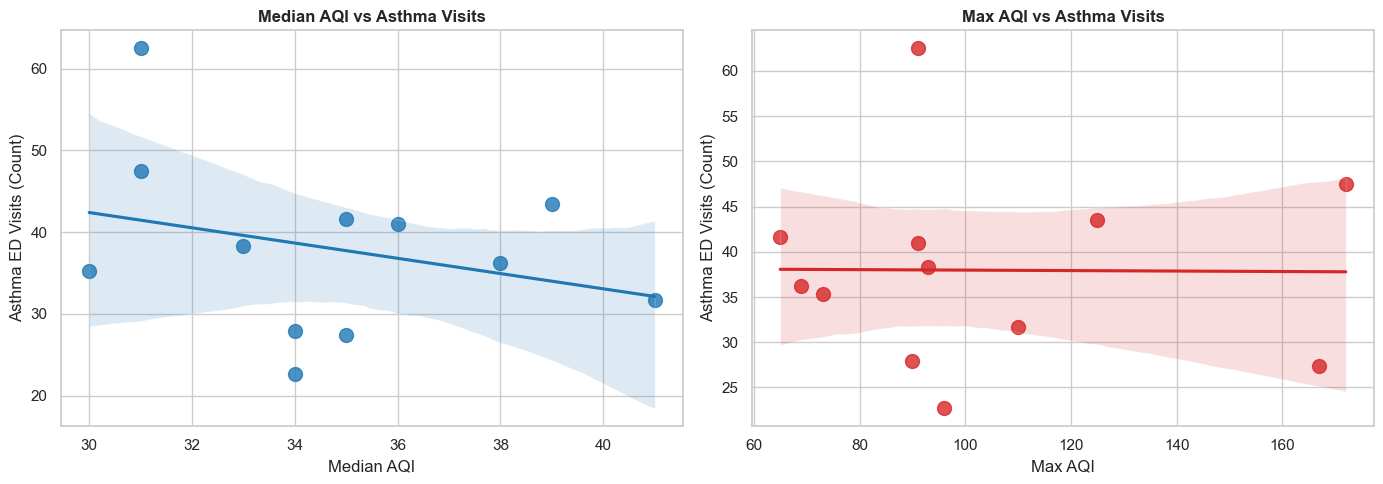

In [288]:
sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(1, 2, figsize = (14, 5))


sns.regplot(data=final_mn_merged, x = 'Median_AQI', y = 'Count', ax = axes[0], color = '#1f77b4', scatter_kws = {'s':100})
axes[0].set_title('Median AQI vs Asthma Visits', fontweight='bold')
axes[0].set_xlabel('Median AQI')
axes[0].set_ylabel('Asthma ED Visits (Count)')


sns.regplot(data = final_mn_merged, x = 'Max_AQI', y = 'Count', ax = axes[1], color = '#d62728', scatter_kws = {'s':100})
axes[1].set_title('Max AQI vs Asthma Visits', fontweight = 'bold')
axes[1].set_xlabel('Max AQI')
axes[1].set_ylabel('Asthma ED Visits (Count)')

plt.tight_layout()
plt.show()

This monthly data also shows no correlation between the variables, with two massive outliers in both comparisons. On the left, the high blue dot (ED visits around 62) is the September hospital rush we discovered earlier. At the same time Median AQI was around 31. On the right plot, the red dot which is down and to the right (Max AQI around 170), had one of the lowest asthma visit counts of the year, around 27.

### Conclusion:
Our investigation was not able to demonstrate any linear relationship between the data we explored about air pollution and asthma prevalence/ED visits. This suggests that asthma has complicated origins and triggers that do not depend solely on air quality but are influenced by allergies, healthcare infrastructure, poverty, human behavior, etc. In addition, as mentioned under *Challenges* above, the publicly available health data on asthma does not provide the full picture of this disease.

What our investigation was able to find:

- air quality, even extreme weather events, do not necessarily increase asthma prevelance or ED visits
- Covid-19 had a tremendous impact on air quality data and asthma ED visits
- demonstrated that asthma is seasonally dependent with a well-established peak in September
- asthma prevalence in urban counties is slightly lower compared to rural and suburban counties


### Sources:
https://aafa.org/asthma/asthma-triggers-causes/air-pollution-smog-asthma/

https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/

https://www.nature.com/articles/s41598-025-88807-6

https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023

https://aqs.epa.gov/aqsweb/airdata/download_files.html

https://www.cdc.gov/brfss/annual_data/annual_data.htm

https://www.cdc.gov/brfss/annual_data/2023/pdf/2023-calculated-variables-version4-508.pdf

https://data.cdc.gov/

https://healthdata.gov/State/Asthma-Emergency-Department-Visit-Rates/28nb-65xq/about_data

https://data.web.health.state.mn.us/web/mndata/asthma_ed

https://www.epa.gov/sites/default/files/2015-05/documents/az_deq_july_2011_pm10_ee_demo_final_20120308.pdf

https://www.ers.usda.gov/data-products/rural-urban-continuum-codes

https://journals.sagepub.com/doi/10.4187/respcare.20223777483

https://en.wikipedia.org/wiki/List_of_California_wildfires

https://pmc.ncbi.nlm.nih.gov/articles/PMC7202457/

https://www.pnas.org/doi/10.1073/pnas.1518677113

https://entirafamilyclinics.com/spring-allergies-in-minnesota-whats-triggering-them-and-how-to-find-relief/

https://www.facebook.com/mnhealth/posts/minnesota-sees-more-asthma-related-emergency-room-visits-in-the-fall-changes-in-/1915960761783705/